# Phase 2 — GreenOQ Index (GQI)

Quality index for green onion genotypes across shelf life, combining consumer perception with physicochemical data.

**Model**

1. **Weights**
   - Visible variables (length *L*, diameter *D*, hue *h*) → consumer perception surveys A + B.
   - Lab variables (firmness *F*, pyruvic acid *AP*) → communality from a PCA on the physicochemical data.
   - Both blocks are combined with equal mass (50 % visible / 50 % lab).
2. **Index** (0–100)
   - *L*, *D* → increasing min–max utility; *F* → decreasing min–max utility.
   - *h*, *AP* → Gaussian penalty (they have an optimum, not a maximum).
3. **Classification** — Low / Medium / High quality by terciles of the mean GQI per genotype.

**Inputs** (in `data/`, not included in the repository):

| File | Sheet | Content |
|---|---|---|
| `ANALISIS FISICOQUIMICO COMPLETO.xlsx` | `Sheet1` | Physicochemical analysis per genotype and time |
| `AcPiruvicoVidaUtil.xlsx` | `AcPiruvico` | Pyruvic acid at T1 and T4 |

**Outputs** (in `results/`): `GreenOQ_results.csv` (GQI per genotype × time) and `GQI_classification.csv`.

## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

%matplotlib inline

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["font.size"] = 12
DPI = 180
FIGSIZE_WEIGHTS = (11, 5.5)   # single size for the weight-derivation figures (G1-G7)
FIGSIZE_QUALITY = (11, 6.5)   # single size for the quality-classification figures (1-4)


def close_axes(ax):
    """Full black frame and outward ticks."""
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
        spine.set_edgecolor("black")
    ax.tick_params(direction="out", length=4, width=1.0)


# ------------------------------------------------------------
# PATHS — run from the repository root or from notebooks/
# ------------------------------------------------------------
ROOT = Path.cwd() if (Path.cwd() / "data").is_dir() else Path.cwd().parent
DATA_DIR = ROOT / "data"
RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

PHYS_PATH = DATA_DIR / "ANALISIS FISICOQUIMICO COMPLETO.xlsx"   # physicochemical data
PYR_PATH = DATA_DIR / "AcPiruvicoVidaUtil.xlsx"                   # pyruvic acid
PHYS_SHEET = "Sheet1"
PYR_SHEET = "AcPiruvico"

# Physicochemical columns used in the PCA (exact names in the Excel file)
PHYS_COLS = ["Pseudosteam length (cm)", "Pseudosteam Diameter (cm)", "Pseudosteam Hue",
             "Pseudosteam Chroma", "Pseudosteam Luminosity", "Firmness (N)",
             "Fresh weight (g)", "TSS (°BRIX)", "TTA (%)", "Chlorophyll relative content (SPAD)"]
AP_COL = "AP [mg/gCebollaSeca]"

VARS = ["Length", "Diameter", "Hue", "Firmness", "Pyruvic acid"]
SYMBOL = {"Length": "L", "Diameter": "D", "Hue": "h", "Firmness": "F", "Pyruvic acid": "AP"}
VISIBLE = ["Length", "Diameter", "Hue"]     # perceived by consumers
LAB = ["Firmness", "Pyruvic acid"]          # measured in the lab

# Species as stored in the data -> label shown in figures
SPECIES_LABEL = {"A fistulosum": "A. fistulosum", "Hibrid": "Hybrid"}

## 2. Load data and build genotype × time means

Pyruvic acid was measured only at T1 and T4, so T2 and T3 are linearly interpolated within each genotype.

In [2]:
phys = pd.read_excel(PHYS_PATH, sheet_name=PHYS_SHEET)
pyr = pd.read_excel(PYR_PATH, sheet_name=PYR_SHEET)

# The source spreadsheets use Spanish column names
phys = phys.rename(columns={"Genotipo": "Genotype", "Tiempo": "Time", "Especie": "Species"})
pyr = pyr.rename(columns={"Material": "Genotype", "Tiempo": "Time"})

# Column check (fails clearly if a name does not match)
missing_phys = [c for c in ["Genotype", "Time", "Species", *PHYS_COLS] if c not in phys.columns]
missing_pyr = [c for c in ["Genotype", "Time", AP_COL] if c not in pyr.columns]
if missing_phys:
    raise ValueError(f"Missing columns in {PHYS_PATH.name}: {missing_phys}")
if missing_pyr:
    raise ValueError(f"Missing columns in {PYR_PATH.name}: {missing_pyr}")

for c in PHYS_COLS:
    phys[c] = pd.to_numeric(phys[c], errors="coerce")
phys["Genotype"] = phys["Genotype"].astype(str).str.strip()
phys["Time"] = pd.to_numeric(phys["Time"], errors="coerce").astype(int)

pyr["Genotype"] = pyr["Genotype"].astype(str).str.strip()
pyr["AP"] = pd.to_numeric(pyr[AP_COL], errors="coerce")
# Pyruvic acid time is text (T1, T4) -> keep the number to join with the physicochemical data
pyr["Time"] = pyr["Time"].astype(str).str.extract(r"(\d+)", expand=False).astype(int)

phys_means = phys.groupby(["Genotype", "Time"])[PHYS_COLS].mean().reset_index()
pyr_means = pyr.groupby(["Genotype", "Time"])["AP"].mean().reset_index()
M = (phys_means.merge(pyr_means, on=["Genotype", "Time"], how="left")
               .sort_values(["Genotype", "Time"]))
M["AP"] = M.groupby("Genotype")["AP"].transform(lambda s: s.interpolate(limit_direction="both"))

species = phys.groupby("Genotype")["Species"].first()

print(f"Genotypes: {M['Genotype'].nunique()}  |  Times: {sorted(M['Time'].unique().tolist())}  |  Rows: {len(M)}")

Genotypes: 10  |  Times: [1, 2, 3, 4]  |  Rows: 40


## 3. Weights

### 3a. Perceptual weights — visible variables (surveys A + B)

In [3]:
SURVEY_A = {"Length": 69, "Diameter": 69, "Hue": 74, "Firmness": 84, "Pyruvic acid": 62}  # published survey (paper, Fig. 6D)
SURVEY_B = {"Length": 80, "Diameter": 76, "Hue": 76}                                      # own survey (visible variables only)
BETA = 0.5   # weight of survey A vs. survey B for the visible variables

imp_visible = np.array([BETA * SURVEY_A[v] + (1 - BETA) * SURVEY_B[v] for v in VISIBLE])   # in VISIBLE order
share_visible = imp_visible / imp_visible.sum()   # internal share of the visible block

print("=" * 60); print("WEIGHTS — DERIVATION"); print("=" * 60)
print(f"  Perceptual (visible): {dict(zip(VISIBLE, imp_visible.round(2).tolist()))}")

WEIGHTS — DERIVATION
  Perceptual (visible): {'Length': 74.5, 'Diameter': 72.5, 'Hue': 75.0}


### 3b. Physicochemical weights — lab variables (PCA communality)

Components are retained until they explain ≥ 80 % of the variance; the importance of each variable is its communality weighted by the explained variance of each retained component.

In [4]:
ALL_COLS = PHYS_COLS + ["AP"]
Z = StandardScaler().fit_transform(M[ALL_COLS].dropna().values)
pca = PCA().fit(Z)
k = int(np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.80) + 1)
loadings = pca.components_[:k].T
evr = pca.explained_variance_ratio_[:k]
communality = (loadings**2 * evr).sum(axis=1)

imp_lab = np.array([communality[ALL_COLS.index("Firmness (N)")],
                    communality[ALL_COLS.index("AP")]])           # in LAB order
share_lab = imp_lab / imp_lab.sum()   # internal share of the lab block

print(f"  PCA (lab): {k} components, {np.cumsum(evr)[-1] * 100:.1f}% variance")
print(f"  Communality: {dict(zip(LAB, imp_lab.round(4).tolist()))}")

  PCA (lab): 4 components, 87.0% variance
  Communality: {'Firmness': 0.0802, 'Pyruvic acid': 0.0773}


### 3c. Final weights — equal block mass (50 % visible / 50 % lab)

In [5]:
def block_weights(mass_visible, mass_lab):
    """Combine the internal shares of both blocks with the given masses (normalized to 1)."""
    raw = {v: s * mass_visible for v, s in zip(VISIBLE, share_visible)}
    raw.update({v: s * mass_lab for v, s in zip(LAB, share_lab)})
    total = sum(raw.values())
    return {v: raw[v] / total for v in VARS}


MASS_VISIBLE, MASS_LAB = 0.5, 0.5
WEIGHTS = block_weights(MASS_VISIBLE, MASS_LAB)
W = np.array([WEIGHTS[v] for v in VARS])   # same weights as an array, in VARS order

print("=" * 60); print("FINAL WEIGHTS"); print("=" * 60)
for v in VARS:
    print(f"  {v:14s} w={WEIGHTS[v]:.4f}  ({WEIGHTS[v] * 100:.1f}%)  [{'Surveys A+B' if v in VISIBLE else 'PCA'}]")
print(f"  Sum: {sum(WEIGHTS.values()):.4f}")

FINAL WEIGHTS
  Length         w=0.1678  (16.8%)  [Surveys A+B]
  Diameter       w=0.1633  (16.3%)  [Surveys A+B]
  Hue            w=0.1689  (16.9%)  [Surveys A+B]
  Firmness       w=0.2546  (25.5%)  [PCA]
  Pyruvic acid   w=0.2454  (24.5%)  [PCA]
  Sum: 1.0000


## 4. Index parameters and GQI computation

In [6]:
L_MIN, L_MAX = phys["Pseudosteam length (cm)"].min(), phys["Pseudosteam length (cm)"].max()
D_MIN, D_MAX = phys["Pseudosteam Diameter (cm)"].min(), phys["Pseudosteam Diameter (cm)"].max()
F_MIN, F_MAX = phys["Firmness (N)"].min(), phys["Firmness (N)"].max()

# Gaussian targets (from the data)
H_TARGET = phys.loc[phys["Time"] == 1, "Pseudosteam Hue"].mean()   # fresh white at T1
H_SIGMA = phys["Pseudosteam Hue"].std()
AP_TARGET = pyr["AP"].median()                                     # typical pungency of the panel
AP_SIGMA = pyr["AP"].std()

print("=" * 60); print("REFERENCE PARAMETERS"); print("=" * 60)
print(f"  L:[{L_MIN:.2f},{L_MAX:.2f}]  D:[{D_MIN:.2f},{D_MAX:.2f}]  F:[{F_MIN:.2f},{F_MAX:.2f}]")
print(f"  h_target={H_TARGET:.2f}  sigma_h={H_SIGMA:.2f} | AP_target={AP_TARGET:.3f}  sigma_AP={AP_SIGMA:.3f}")


def utility_increasing(x, lo, hi):
    """More is better."""
    return np.clip((x - lo) / (hi - lo), 0, 1)


def utility_decreasing(x, lo, hi):
    """Less is better."""
    return np.clip(1 - (x - lo) / (hi - lo), 0, 1)


def gaussian(x, target, sigma):
    """Optimum at the target."""
    return np.exp(-((x - target) ** 2) / (2 * sigma**2))


def compute_gqi(data, weights):
    return 100 * (weights["Length"]       * utility_increasing(data["L"], L_MIN, L_MAX)
                  + weights["Diameter"]     * utility_increasing(data["D"], D_MIN, D_MAX)
                  + weights["Firmness"]     * utility_decreasing(data["F"], F_MIN, F_MAX)
                  + weights["Hue"]          * gaussian(data["h"], H_TARGET, H_SIGMA)
                  + weights["Pyruvic acid"] * gaussian(data["AP"], AP_TARGET, AP_SIGMA))


gqi = M.rename(columns={"Pseudosteam length (cm)": "L", "Pseudosteam Diameter (cm)": "D",
                        "Pseudosteam Hue": "h", "Firmness (N)": "F"})
gqi["GQI"] = compute_gqi(gqi, WEIGHTS)

print("\n" + "=" * 60); print("GQI BY GENOTYPE x TIME"); print("=" * 60)
print(gqi.pivot(index="Genotype", columns="Time", values="GQI").round(1).to_string())
print(f"\n  GQI: min={gqi['GQI'].min():.1f}  max={gqi['GQI'].max():.1f}  mean={gqi['GQI'].mean():.1f}")

gqi[["Genotype", "Time", "L", "D", "h", "F", "AP", "GQI"]].to_csv(
    RESULTS_DIR / "GreenOQ_results.csv", index=False)
print(f"\n  Results saved to: {(RESULTS_DIR / 'GreenOQ_results.csv').relative_to(ROOT).as_posix()}")

REFERENCE PARAMETERS
  L:[15.00,30.00]  D:[5.04,23.02]  F:[3.43,30.01]
  h_target=102.89  sigma_h=16.02 | AP_target=0.942  sigma_AP=0.714

GQI BY GENOTYPE x TIME
Time          1     2     3     4
Genotype                         
91400028   73.5  69.9  63.5  56.9
91400035   76.7  58.6  45.2  36.8
91400070   72.5  67.3  63.2  55.2
91400071   83.1  81.9  75.6  70.1
ANTSNC003  81.4  75.6  69.0  56.6
ANTSON013  69.9  55.3  49.4  33.3
ANTSRO029  67.4  67.4  61.6  58.9
ANTSRO030  80.3  79.4  74.9  62.5
CUNSBR048  66.4  66.3  64.7  53.0
NDSCAR038  75.9  74.6  60.6  53.9

  GQI: min=33.3  max=83.1  mean=65.2

  Results saved to: results/GreenOQ_results.csv


### 4b. Alternative weighting schemes (sensitivity check)

Earlier versions of the model used other weights. They are kept here for comparison:

- **Survey only** — all five weights from surveys A + B, no PCA (first version).
- **Surveys + PCA, 60/40** — 60 % visible block / 40 % lab block.
- **Surveys + PCA, 50/50** — final model.

In [7]:
def survey_only_weights():
    """Survey A + B for the visible variables, survey A for firmness and pyruvic acid."""
    imp = {v: BETA * SURVEY_A[v] + (1 - BETA) * SURVEY_B[v] if v in VISIBLE else SURVEY_A[v]
           for v in VARS}
    total = sum(imp.values())
    return {v: imp[v] / total for v in VARS}


schemes = {
    "Survey only": survey_only_weights(),
    "Surveys+PCA 60/40": block_weights(0.6, 0.4),
    "Surveys+PCA 50/50 (final)": WEIGHTS,
}

print("Weights (%):")
print(pd.DataFrame(schemes).mul(100).round(1).to_string())

print("\nMean GQI per genotype:")
mean_gqi_by_scheme = pd.DataFrame({name: compute_gqi(gqi, w).groupby(gqi["Genotype"]).mean()
                                   for name, w in schemes.items()})
print(mean_gqi_by_scheme.sort_values("Surveys+PCA 50/50 (final)", ascending=False).round(1).to_string())

Weights (%):
              Survey only  Surveys+PCA 60/40  Surveys+PCA 50/50 (final)
Length               20.2               20.1                       16.8
Diameter             19.7               19.6                       16.3
Hue                  20.4               20.3                       16.9
Firmness             22.8               20.4                       25.5
Pyruvic acid         16.8               19.6                       24.5

Mean GQI per genotype:
           Survey only  Surveys+PCA 60/40  Surveys+PCA 50/50 (final)
Genotype                                                            
91400071          75.7               76.6                       77.7
ANTSRO030         72.8               73.7                       74.2
ANTSNC003         69.9               70.8                       70.6
NDSCAR038         65.6               66.2                       66.2
91400028          62.7               63.4                       65.9
91400070          63.5               63.3       

## 5. Quality classification (terciles: Low / Medium / High)

In [8]:
mean_by_genotype = gqi.groupby("Genotype")["GQI"].mean().sort_values(ascending=False)
q1, q2 = mean_by_genotype.quantile([1 / 3, 2 / 3])


def quality_class(value):
    return "Low" if value < q1 else ("Medium" if value < q2 else "High")


summary = pd.DataFrame({"GQI": mean_by_genotype,
                        "Class": [quality_class(v) for v in mean_by_genotype],
                        "Species": [species.get(g, "?") for g in mean_by_genotype.index]})
gqi_species = gqi.merge(phys[["Genotype", "Species"]].drop_duplicates(), on="Genotype")

print("=" * 60); print("QUALITY CLASSIFICATION"); print("=" * 60)
print(summary.round(1).to_string())
print(f"\nThresholds: Low<{q1:.1f} | Medium {q1:.1f}-{q2:.1f} | High>{q2:.1f}")

print("\nMean GQI by species:")
for sp, sub in gqi_species.groupby("Species"):
    print(f"  {SPECIES_LABEL.get(sp, sp):14s} {sub['GQI'].mean():.1f}")

summary.to_csv(RESULTS_DIR / "GQI_classification.csv")
print(f"\nSaved: {(RESULTS_DIR / 'GQI_classification.csv').relative_to(ROOT).as_posix()}")

QUALITY CLASSIFICATION
            GQI   Class       Species
Genotype                             
91400071   77.7    High  A fistulosum
ANTSRO030  74.2    High  A fistulosum
ANTSNC003  70.6    High  A fistulosum
NDSCAR038  66.2    High  A fistulosum
91400028   65.9  Medium        Hibrid
91400070   64.5  Medium        Hibrid
ANTSRO029  63.8  Medium  A fistulosum
CUNSBR048  62.6     Low        Hibrid
91400035   54.3     Low  A fistulosum
ANTSON013  52.0     Low        Hibrid

Thresholds: Low<63.8 | Medium 63.8-66.2 | High>66.2

Mean GQI by species:
  A. fistulosum  67.8
  Hybrid         61.3

Saved: results/GQI_classification.csv


## 6. Figures — weight derivation (G1–G7)

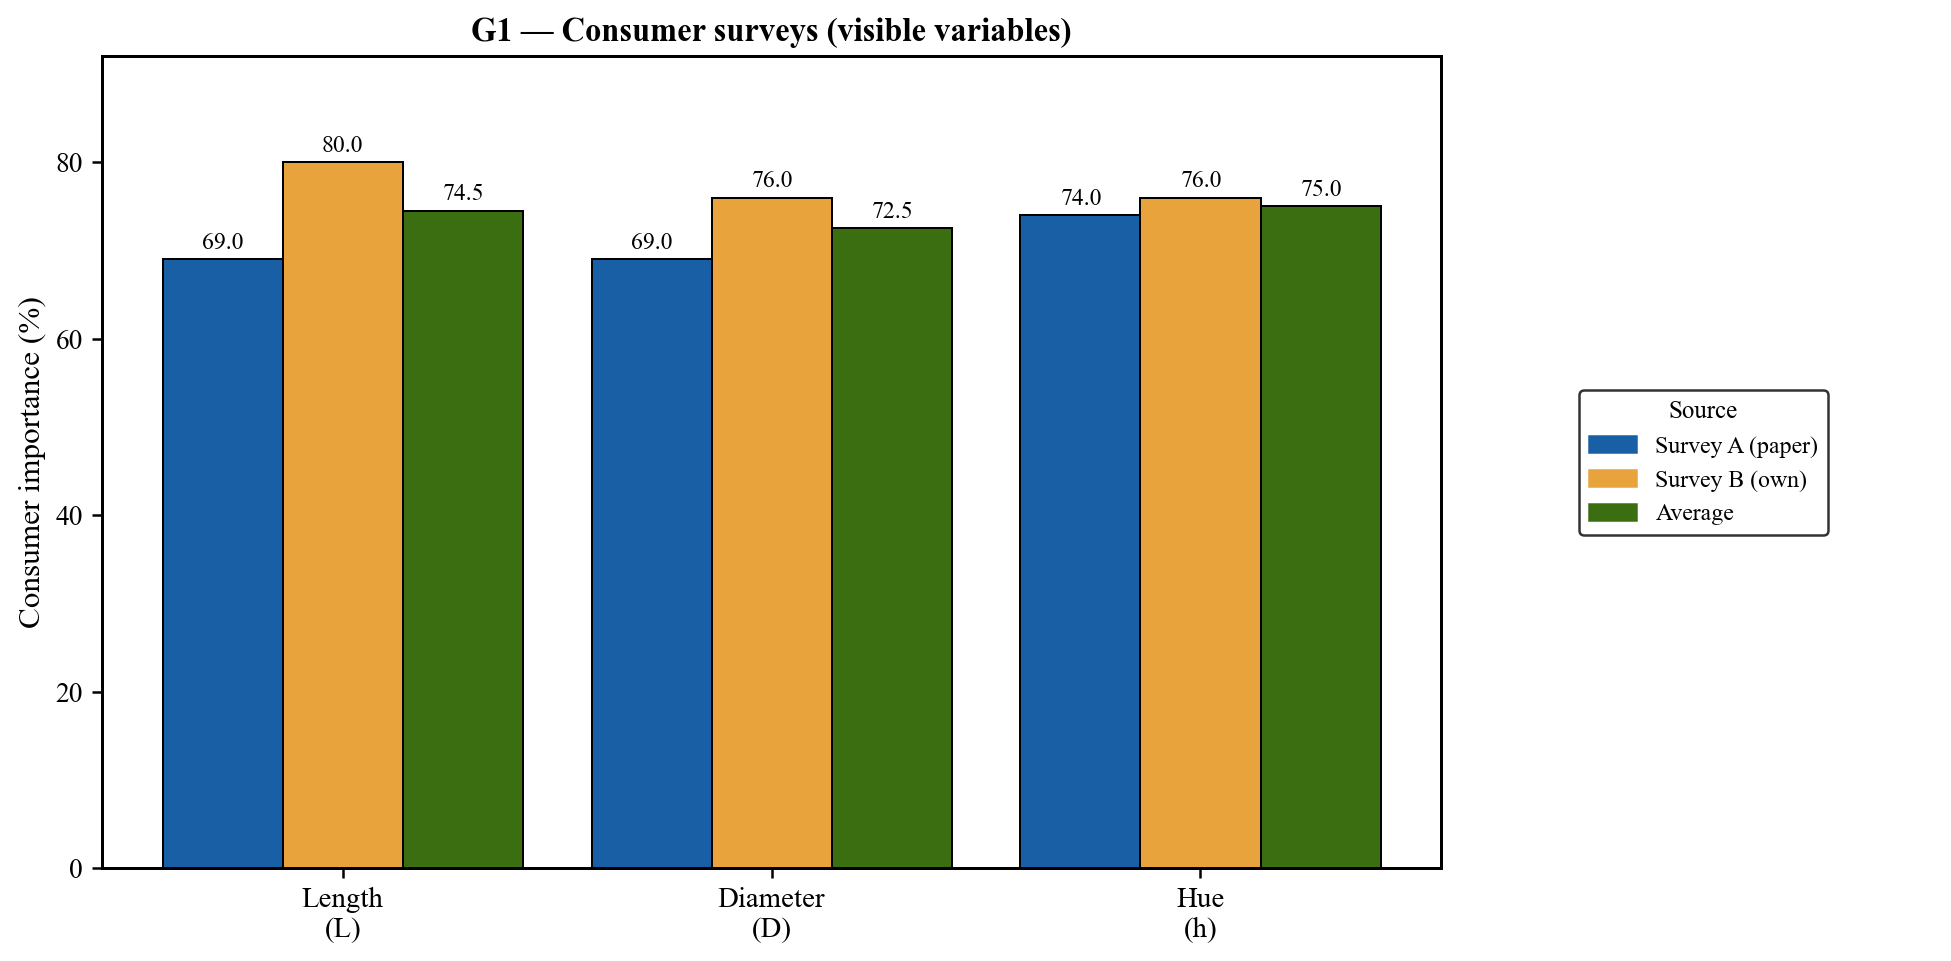

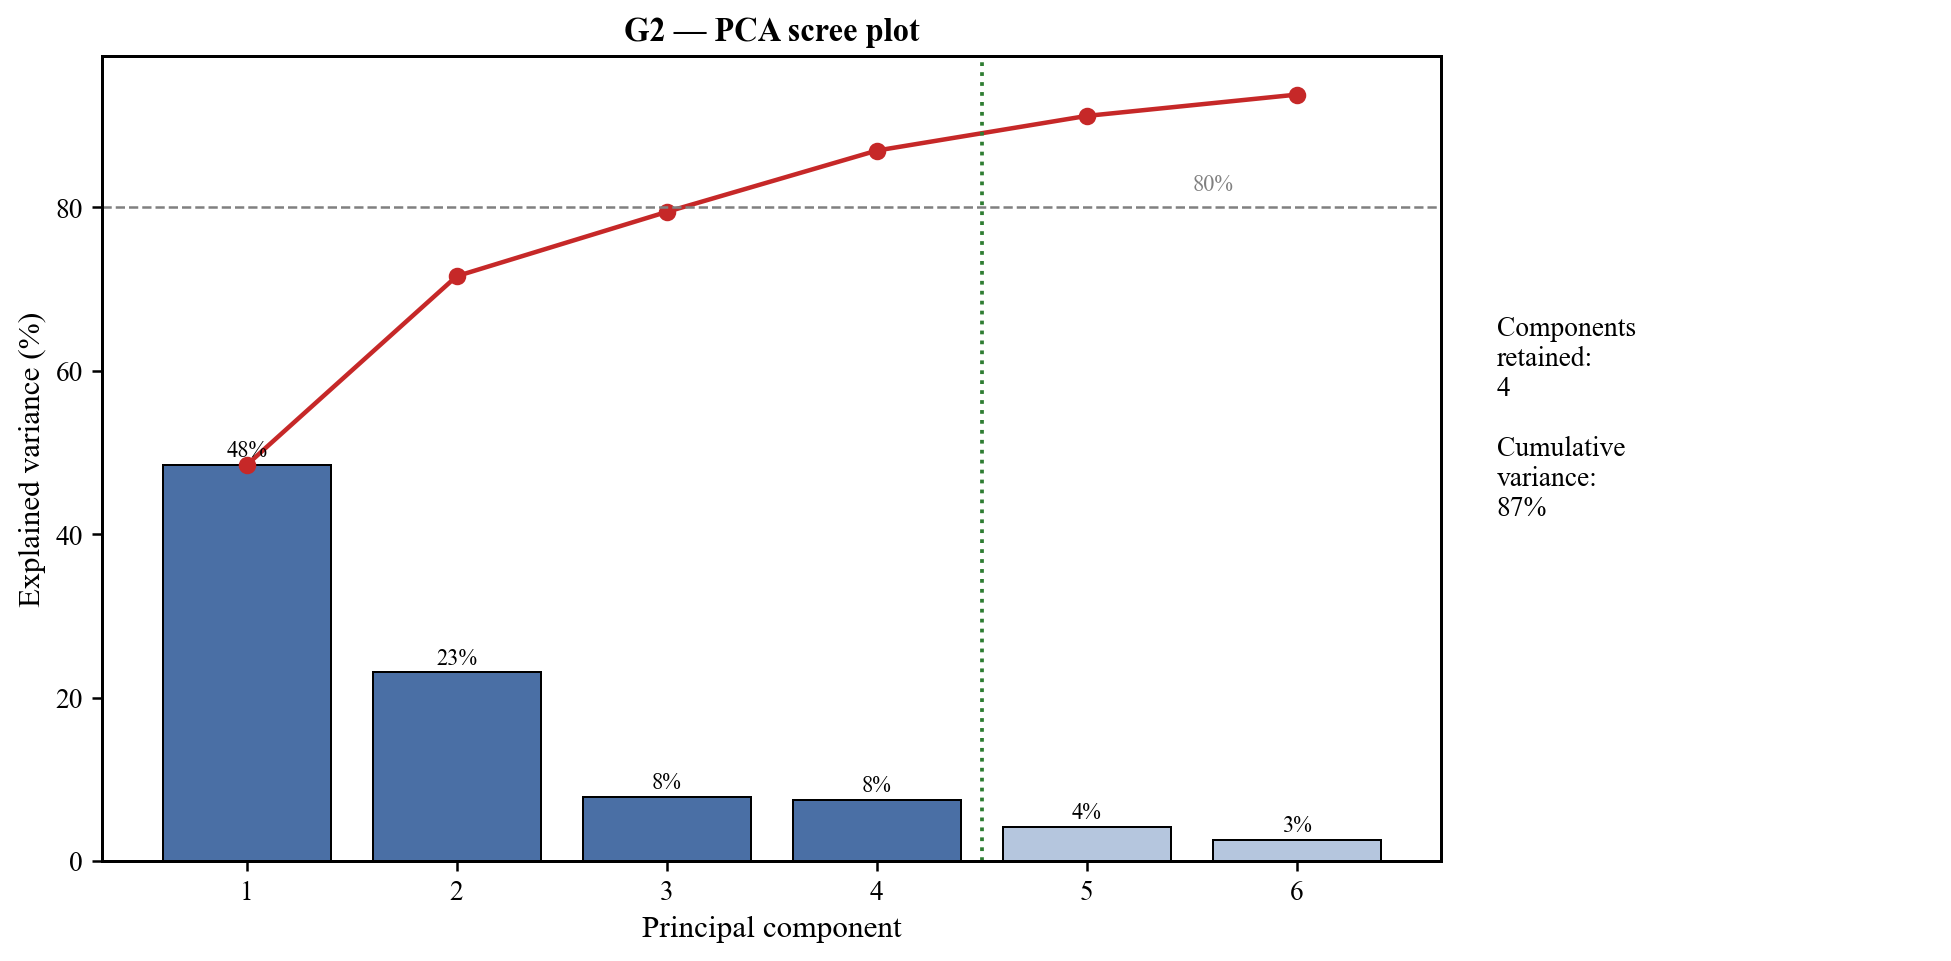

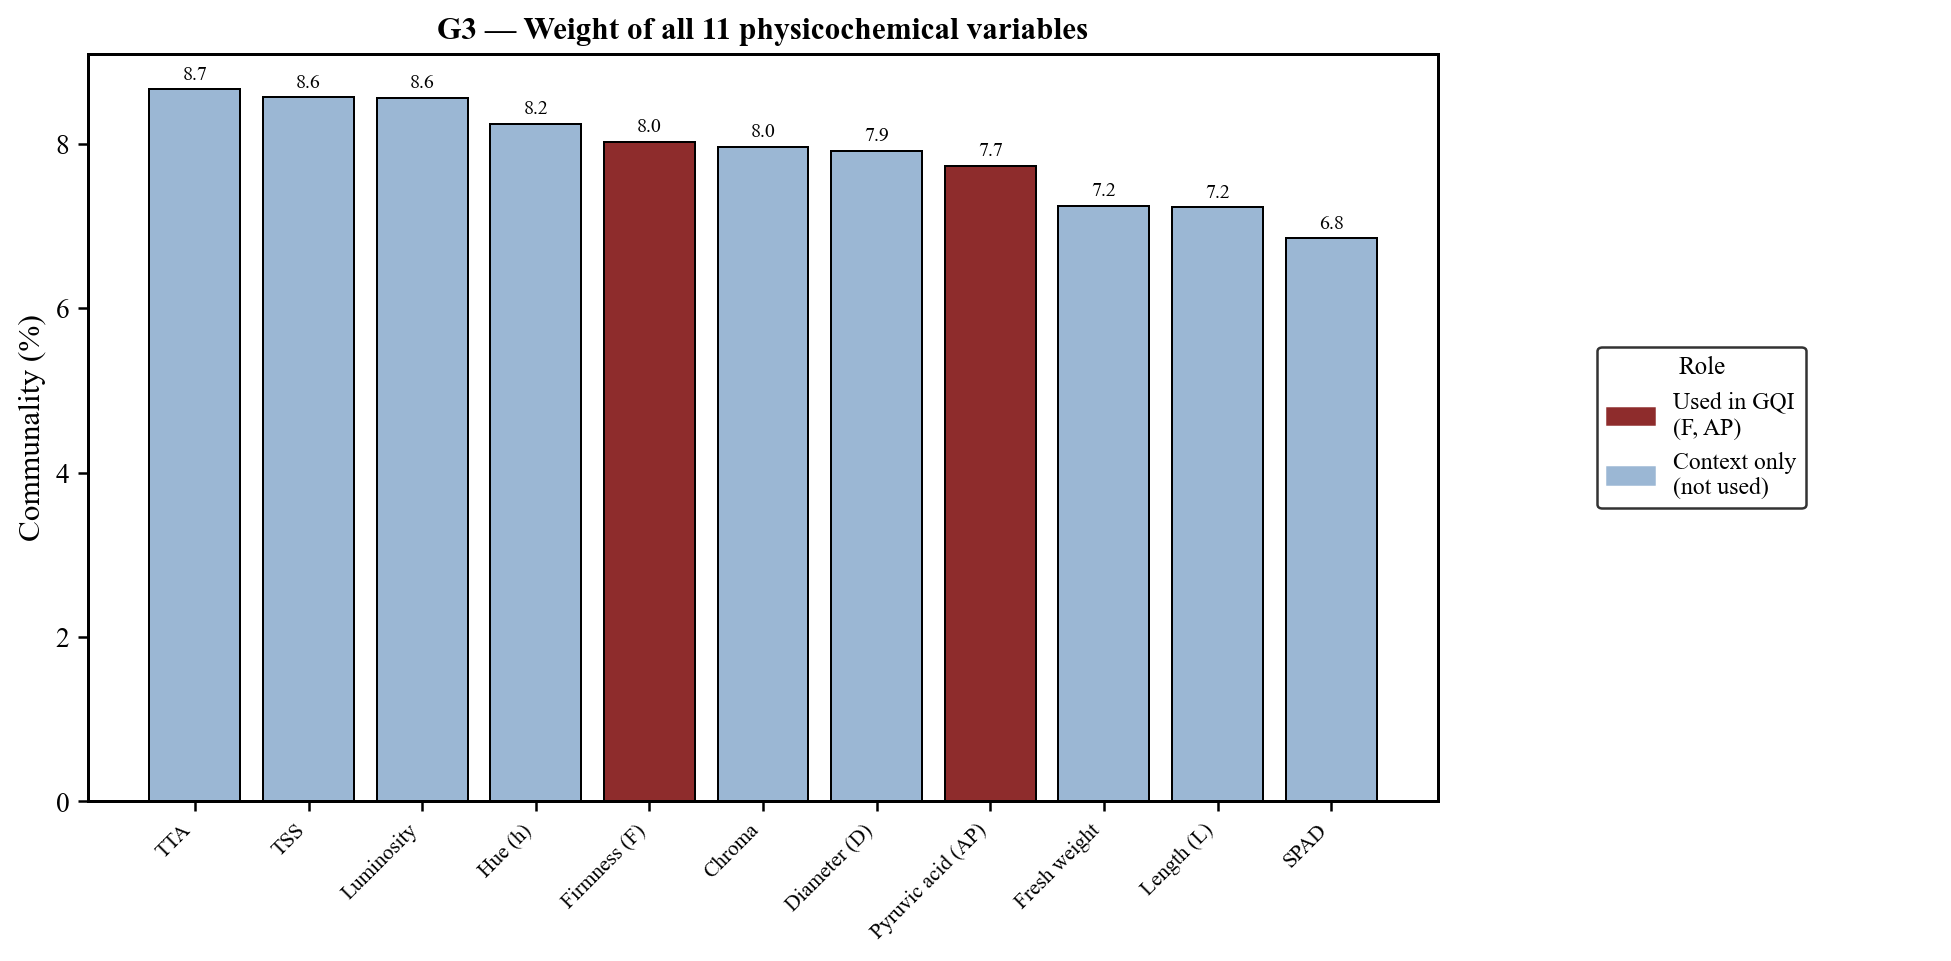

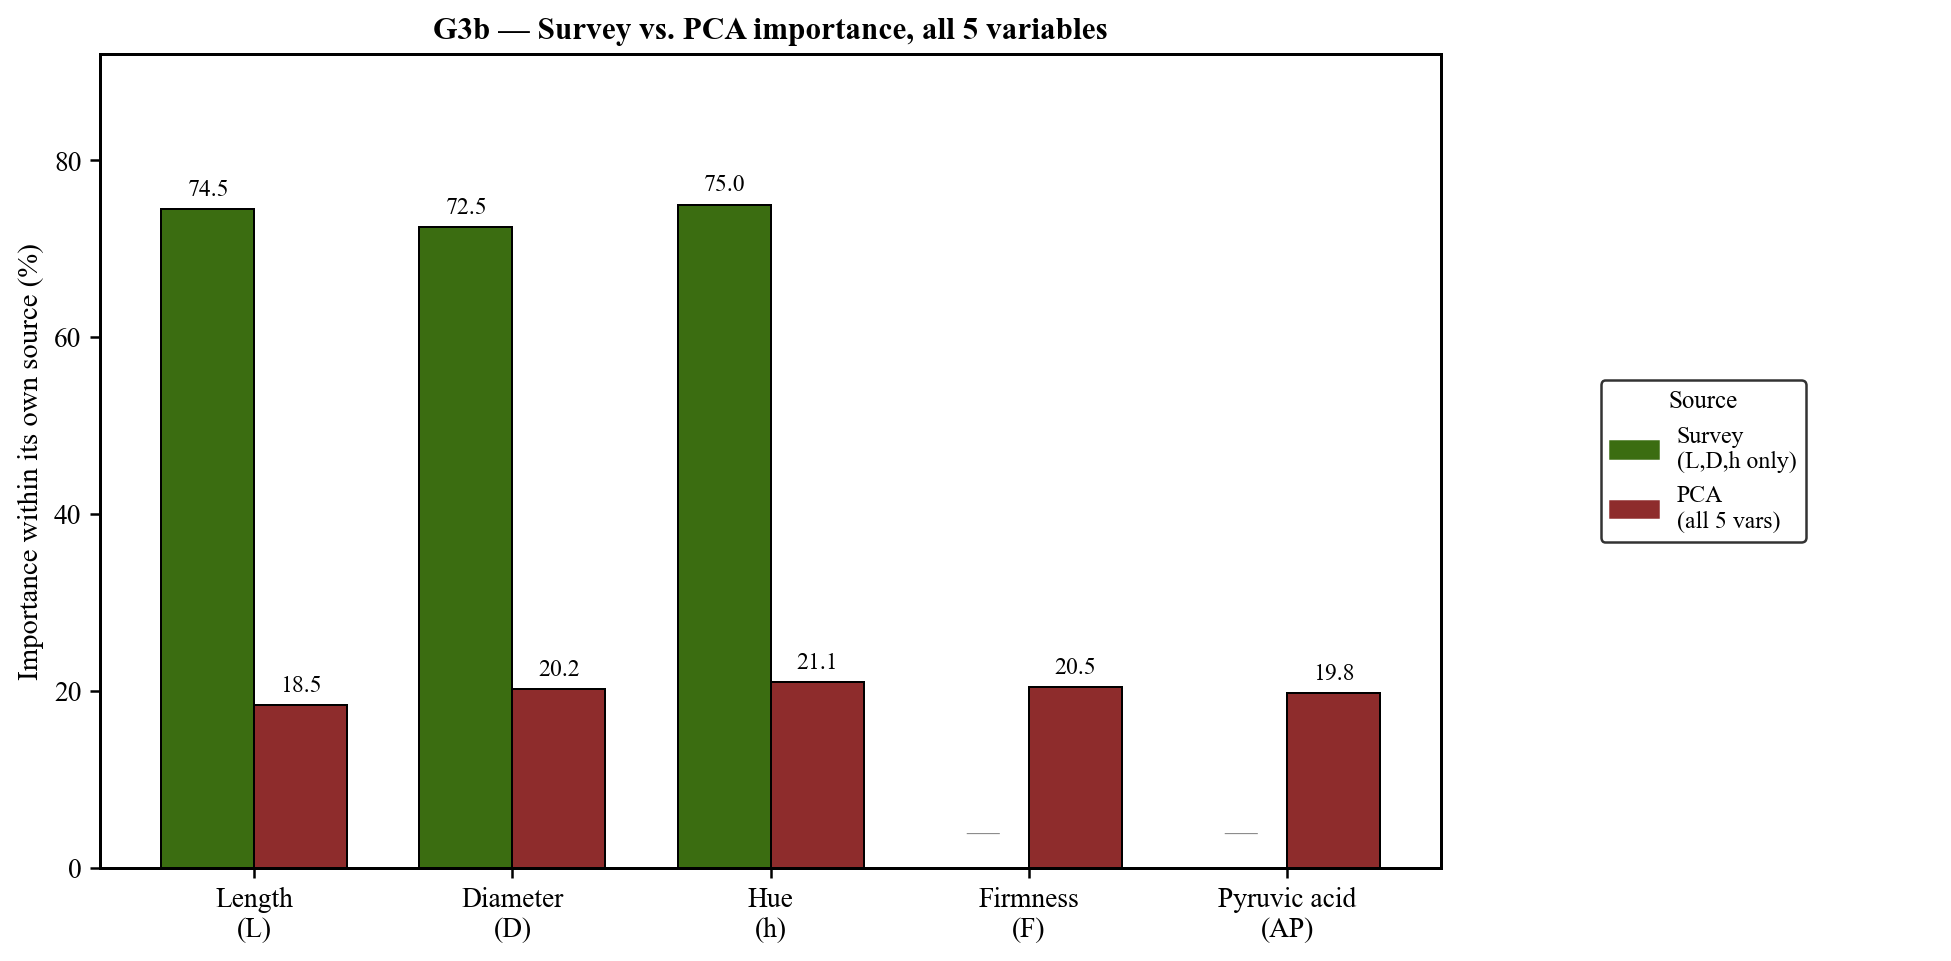

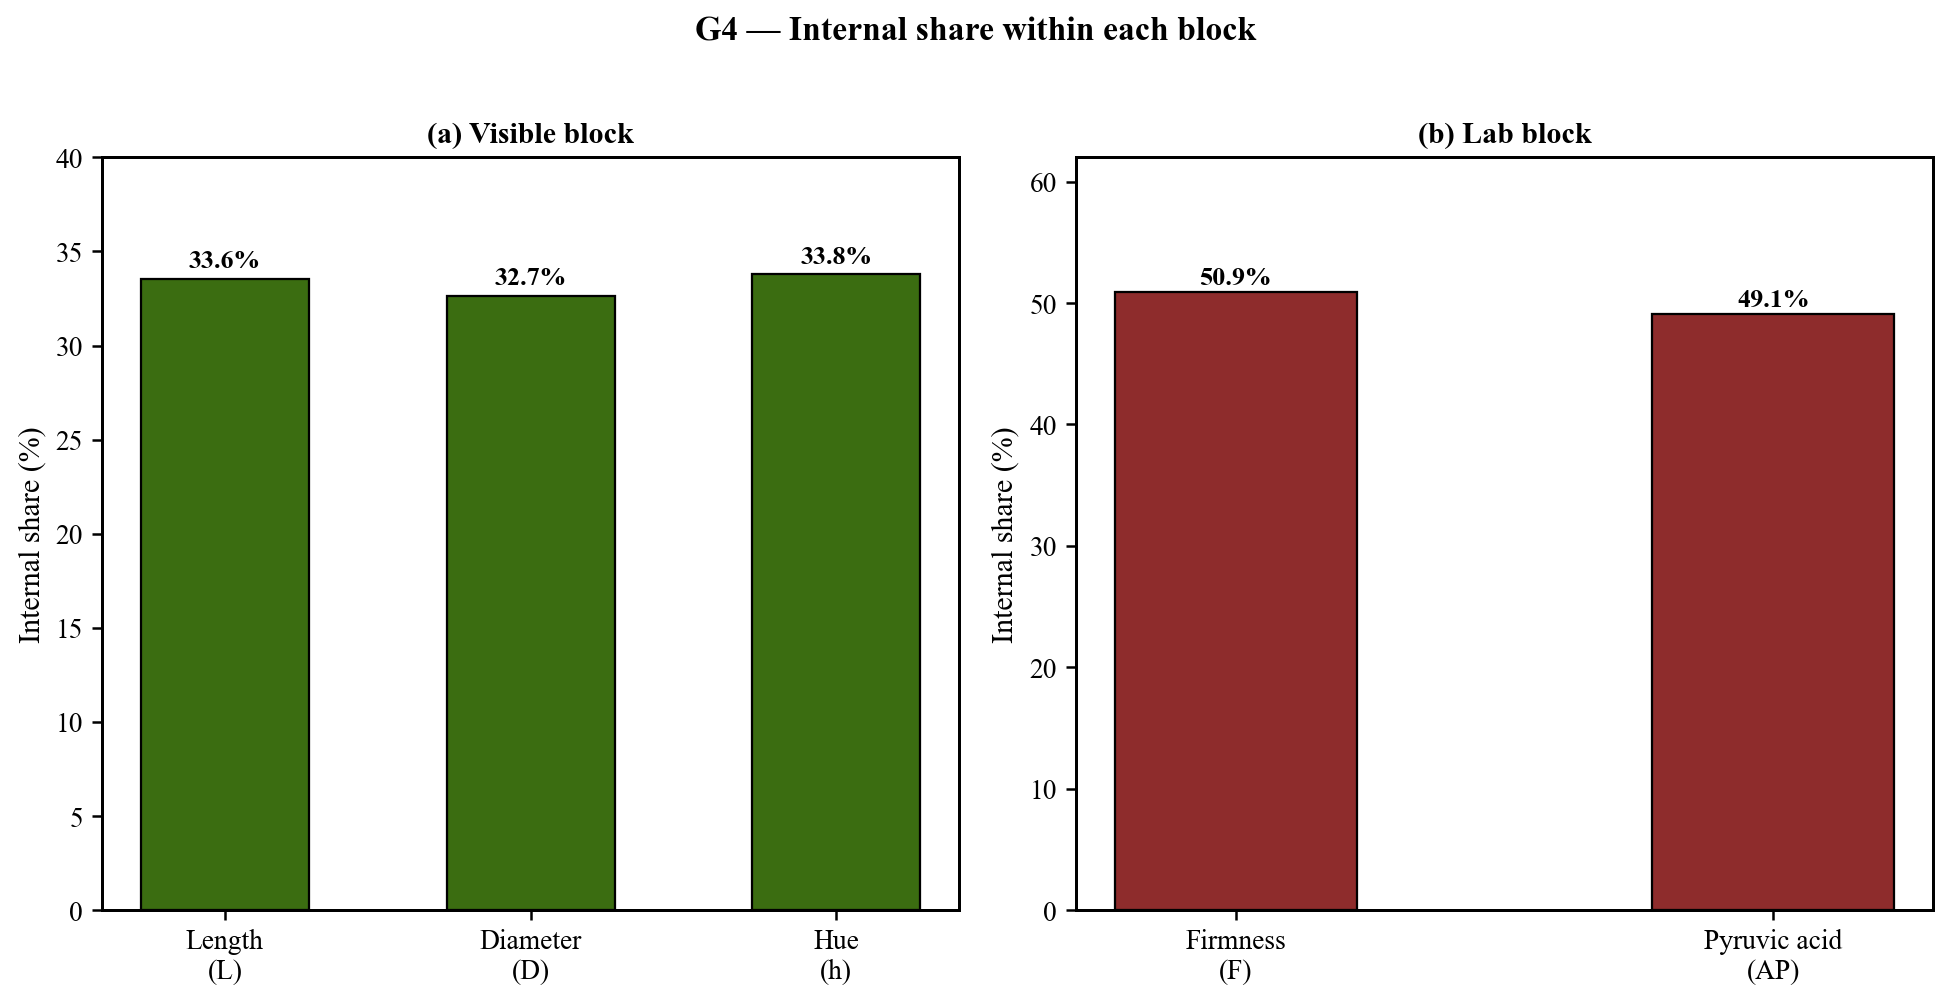

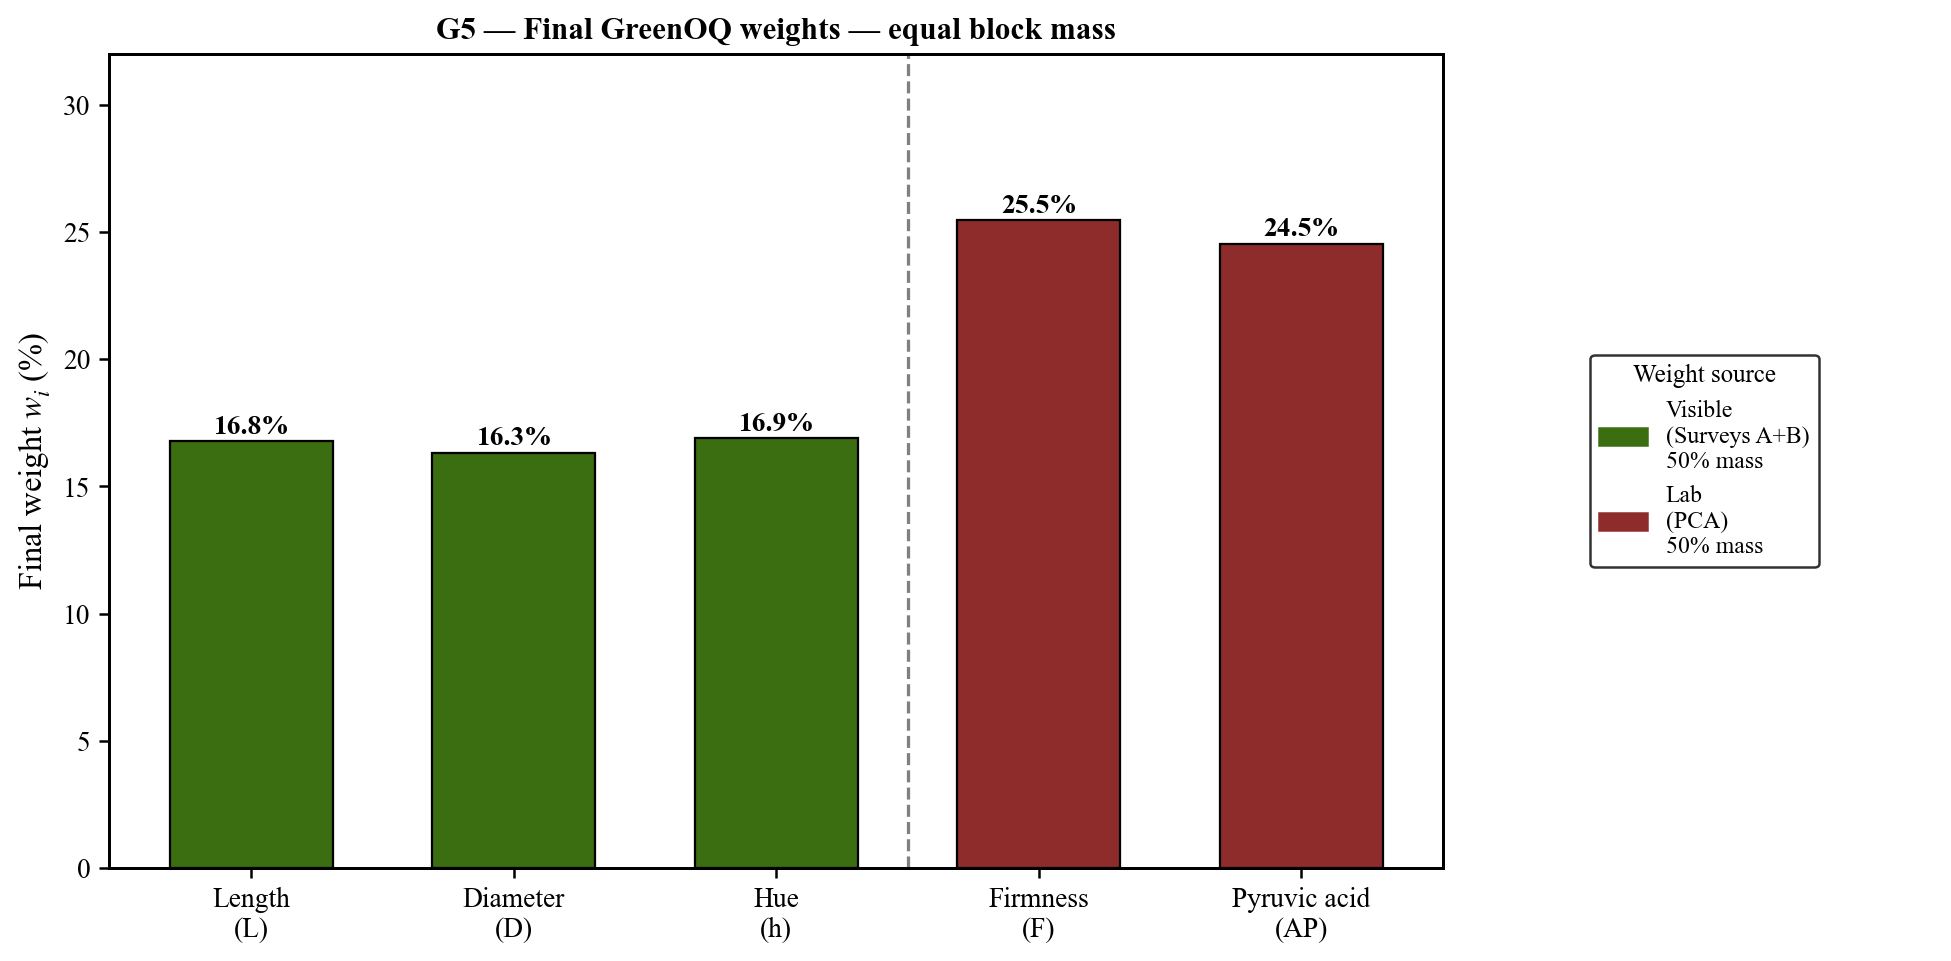

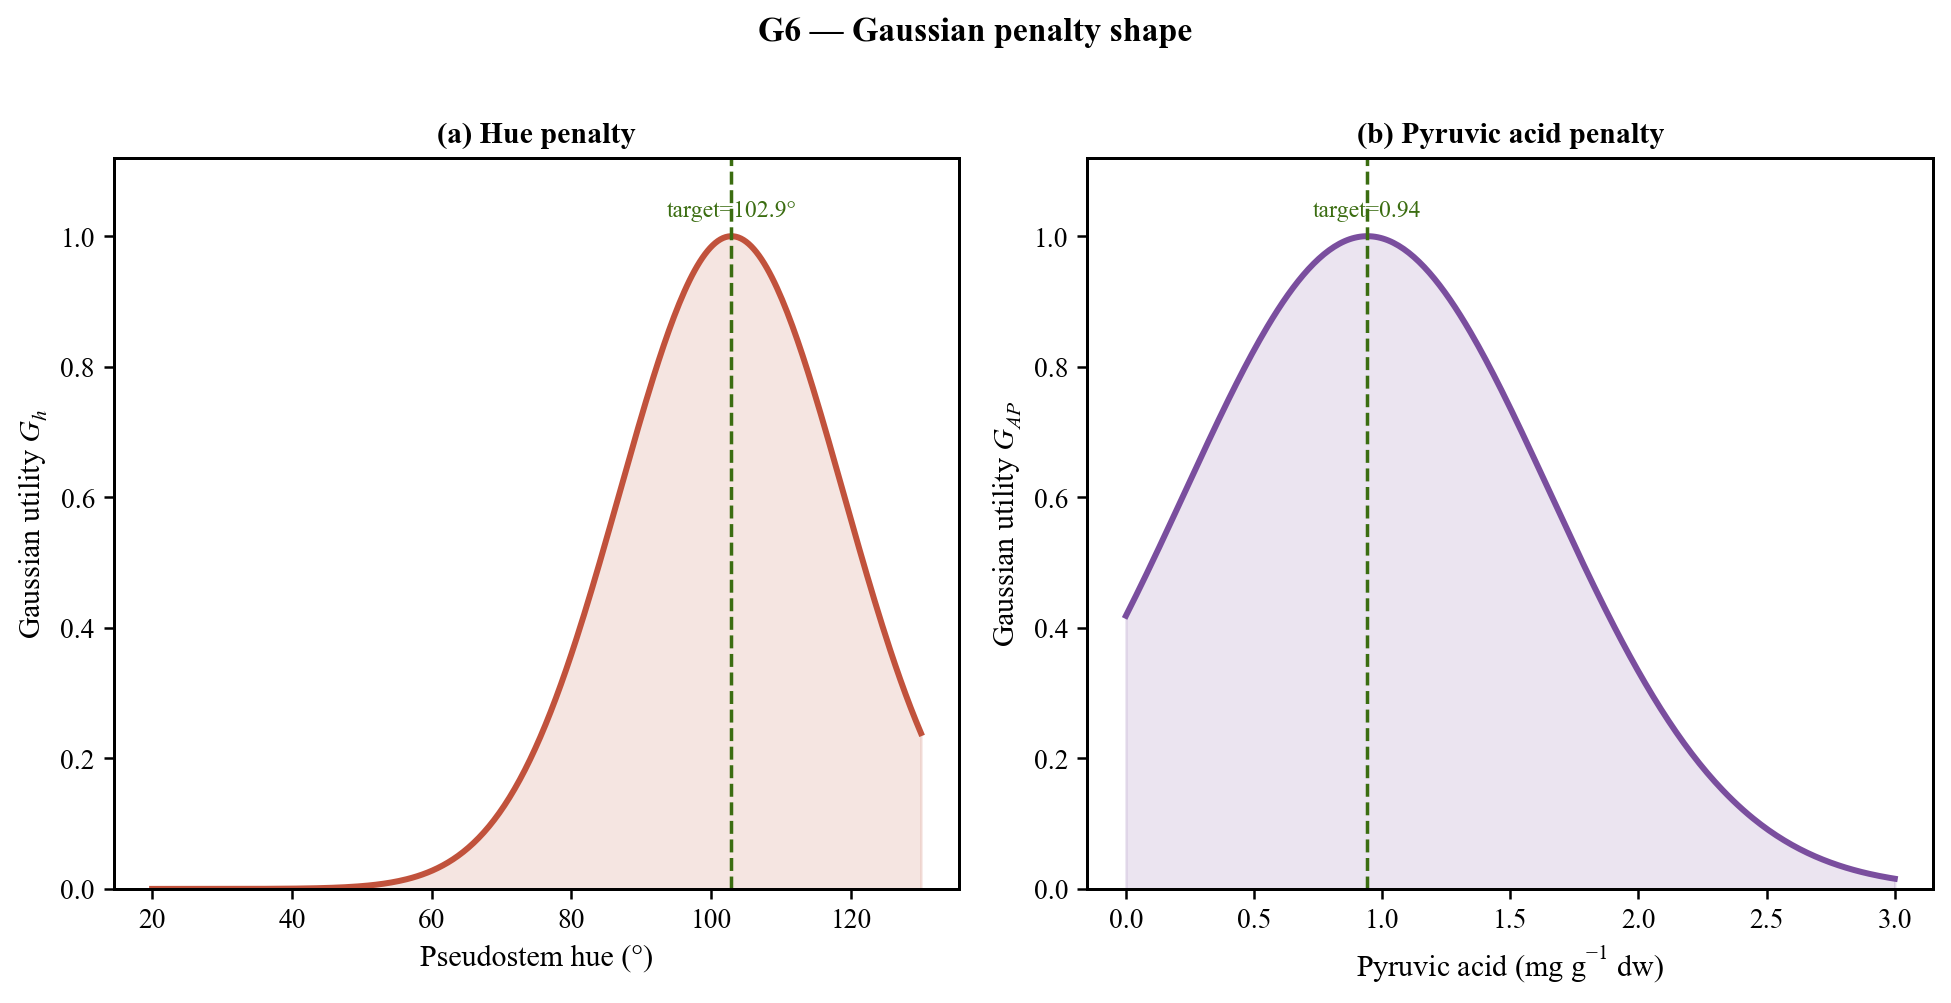

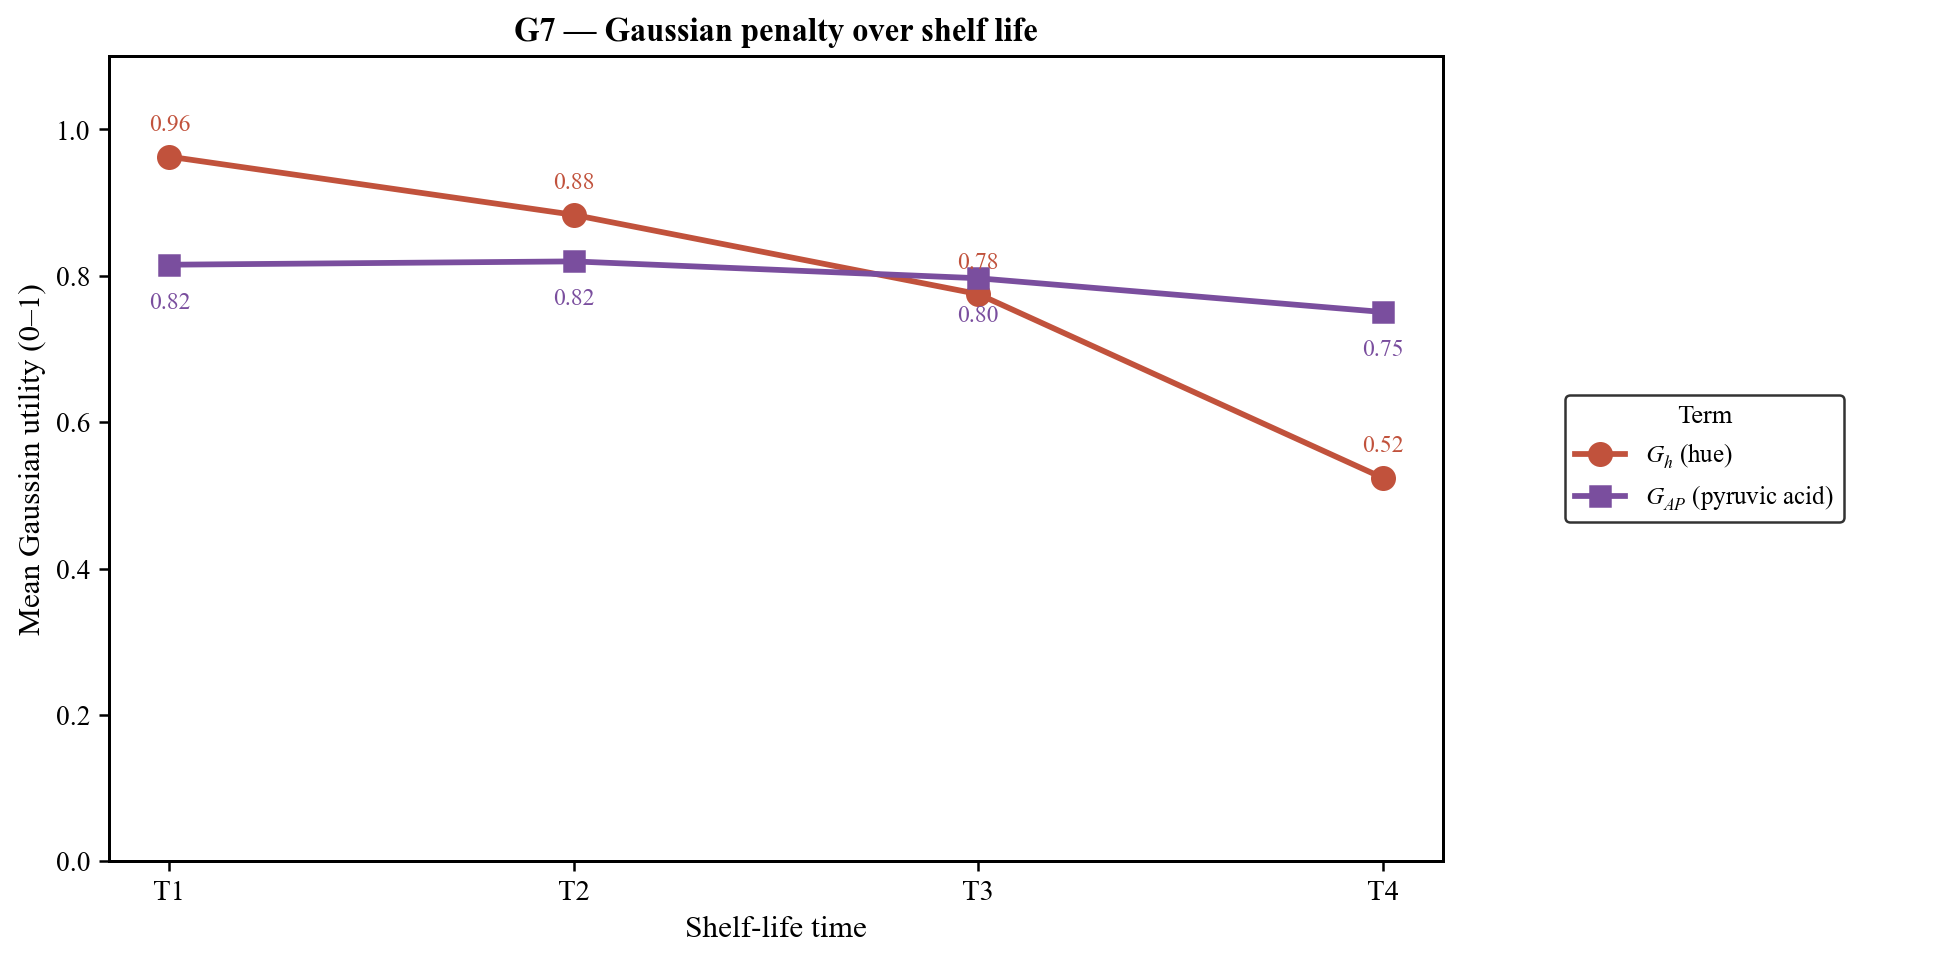

In [9]:
cA, cB, cC, cVis, cLab = "#185FA5", "#E8A33D", "#3B6D11", "#3B6D11", "#8E2C2C"
idx = {v: i for i, v in enumerate(VARS)}

# ---- G1: Consumer surveys ----
fig, (ax, axl) = plt.subplots(1, 2, figsize=FIGSIZE_WEIGHTS, dpi=DPI, gridspec_kw={"width_ratios": [3.5, 1.2]})
x = np.arange(3); w = 0.28
for kk, (vals, c) in enumerate([(np.array([SURVEY_A[v] for v in VISIBLE]), cA),
                                (np.array([SURVEY_B[v] for v in VISIBLE]), cB),
                                (imp_visible, cC)]):
    bars = ax.bar(x + (kk - 1) * w, vals, w, color=c, edgecolor="black", lw=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 1.2, f"{val:.1f}", ha="center", fontsize=9.5)
ax.set_xticks(x); ax.set_xticklabels([f"{v}\n({SYMBOL[v]})" for v in VISIBLE], fontsize=11.5)
ax.set_ylabel("Consumer importance (%)", fontsize=12.5)
ax.set_title("G1 — Consumer surveys (visible variables)", fontsize=13, weight="bold")
ax.set_ylim(0, 92); close_axes(ax)
axl.axis("off")
axl.legend(handles=[mpatches.Patch(color=cA, label="Survey A (paper)"),
                    mpatches.Patch(color=cB, label="Survey B (own)"),
                    mpatches.Patch(color=cC, label="Average")],
           fontsize=9.5, frameon=True, edgecolor="black", loc="center", title="Source", title_fontsize=10)
plt.tight_layout(); plt.show()

# ---- G2: Scree plot ----
fig, (ax, axl) = plt.subplots(1, 2, figsize=FIGSIZE_WEIGHTS, dpi=DPI, gridspec_kw={"width_ratios": [3.5, 1.2]})
ev_all = pca.explained_variance_ratio_[:6] * 100
ax.bar(range(1, len(ev_all) + 1), ev_all, color=["#4A6FA5"] * k + ["#B5C6DE"] * (len(ev_all) - k),
       edgecolor="black", lw=0.8)
ax.plot(range(1, len(ev_all) + 1), np.cumsum(ev_all), "o-", color="#C62828", lw=1.8, ms=6)
for i, e in enumerate(ev_all):
    ax.text(i + 1, e + 1, f"{e:.0f}%", ha="center", fontsize=9)
ax.axhline(80, color="gray", ls="--", lw=1); ax.text(len(ev_all) - 0.3, 82, "80%", fontsize=9, color="gray", ha="right")
ax.axvline(k + 0.5, color="#2E7D32", ls=":", lw=1.5)
ax.set_xlabel("Principal component", fontsize=12.5); ax.set_ylabel("Explained variance (%)", fontsize=12.5)
ax.set_title("G2 — PCA scree plot", fontsize=13, weight="bold"); close_axes(ax)
axl.axis("off")
axl.text(0.05, 0.55, f"Components\nretained:\n{k}\n\nCumulative\nvariance:\n{np.cumsum(evr)[-1] * 100:.0f}%",
         fontsize=11, va="center")
plt.tight_layout(); plt.show()

# ---- G3: Communality of all 11 variables ----
short = {"Pseudosteam length (cm)": "Length (L)", "Pseudosteam Diameter (cm)": "Diameter (D)",
         "Pseudosteam Hue": "Hue (h)", "Pseudosteam Chroma": "Chroma", "Pseudosteam Luminosity": "Luminosity",
         "Firmness (N)": "Firmness (F)", "Fresh weight (g)": "Fresh weight", "TSS (°BRIX)": "TSS",
         "TTA (%)": "TTA", "Chlorophyll relative content (SPAD)": "SPAD", "AP": "Pyruvic acid (AP)"}
labels = [short[c] for c in ALL_COLS]
order = np.argsort(communality)[::-1]
bar_colors = ["#8E2C2C" if ALL_COLS[i] in ["Firmness (N)", "AP"] else "#9BB7D4" for i in order]
fig, (ax, axl) = plt.subplots(1, 2, figsize=FIGSIZE_WEIGHTS, dpi=DPI, gridspec_kw={"width_ratios": [3.5, 1.2]})
ax.bar(range(len(labels)), communality[order] * 100, color=bar_colors, edgecolor="black", lw=0.8)
for i, val in enumerate(communality[order] * 100):
    ax.text(i, val + 0.12, f"{val:.1f}", ha="center", fontsize=8)
ax.set_xticks(range(len(labels))); ax.set_xticklabels([labels[i] for i in order], rotation=45, ha="right", fontsize=8.5)
ax.set_ylabel("Communality (%)", fontsize=12.5)
ax.set_title("G3 — Weight of all 11 physicochemical variables", fontsize=12.5, weight="bold")
close_axes(ax)
axl.axis("off")
axl.legend(handles=[mpatches.Patch(color="#8E2C2C", label="Used in GQI\n(F, AP)"),
                    mpatches.Patch(color="#9BB7D4", label="Context only\n(not used)")],
           fontsize=9.5, frameon=True, edgecolor="black", loc="center", title="Role", title_fontsize=10)
plt.tight_layout(); plt.show()

# ---- G3b: Survey vs. PCA (5 variables) ----
communality5 = np.array([communality[ALL_COLS.index(c)] for c in
                         ["Pseudosteam length (cm)", "Pseudosteam Diameter (cm)", "Pseudosteam Hue", "Firmness (N)", "AP"]])
pca_pct = communality5 / communality5.sum() * 100
survey_pct = np.array([imp_visible[0], imp_visible[1], imp_visible[2], np.nan, np.nan])
fig, (ax, axl) = plt.subplots(1, 2, figsize=FIGSIZE_WEIGHTS, dpi=DPI, gridspec_kw={"width_ratios": [3.5, 1.2]})
x = np.arange(5); w = 0.36
ax.bar(x - w / 2, np.nan_to_num(survey_pct, nan=0), w, color=cVis, edgecolor="black", lw=0.8)
for i in range(5):
    if not np.isnan(survey_pct[i]):
        ax.text(x[i] - w / 2, survey_pct[i] + 1.5, f"{survey_pct[i]:.1f}", ha="center", fontsize=9.5)
    else:
        ax.text(x[i] - w / 2, 3, "—", ha="center", fontsize=13, color="#888888")
ax.bar(x + w / 2, pca_pct, w, color=cLab, edgecolor="black", lw=0.8)
for i, v in enumerate(pca_pct):
    ax.text(x[i] + w / 2, v + 1.5, f"{v:.1f}", ha="center", fontsize=9.5)
ax.set_xticks(x); ax.set_xticklabels([f"{v}\n({SYMBOL[v]})" for v in VARS], fontsize=11)
ax.set_ylabel("Importance within its own source (%)", fontsize=11.5)
ax.set_title("G3b — Survey vs. PCA importance, all 5 variables", fontsize=12.5, weight="bold")
ax.set_ylim(0, 92); close_axes(ax)
axl.axis("off")
axl.legend(handles=[mpatches.Patch(color=cVis, label="Survey\n(L,D,h only)"),
                    mpatches.Patch(color=cLab, label="PCA\n(all 5 vars)")],
           fontsize=9.5, frameon=True, edgecolor="black", loc="center", title="Source", title_fontsize=10)
plt.tight_layout(); plt.show()

# ---- G4: Internal share within each block ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=FIGSIZE_WEIGHTS, dpi=DPI)
ax1.bar(range(3), share_visible * 100, color=cVis, edgecolor="black", lw=0.9, width=0.55)
for i, val in enumerate(share_visible * 100):
    ax1.text(i, val + 0.6, f"{val:.1f}%", ha="center", fontsize=10.5, weight="bold")
ax1.set_xticks(range(3)); ax1.set_xticklabels([f"{v}\n({SYMBOL[v]})" for v in VISIBLE], fontsize=11)
ax1.set_ylabel("Internal share (%)", fontsize=12); ax1.set_ylim(0, 40)
ax1.set_title("(a) Visible block", fontsize=12, weight="bold"); close_axes(ax1)
ax2.bar(range(2), share_lab * 100, color=cLab, edgecolor="black", lw=0.9, width=0.45)
for i, val in enumerate(share_lab * 100):
    ax2.text(i, val + 0.6, f"{val:.1f}%", ha="center", fontsize=10.5, weight="bold")
ax2.set_xticks(range(2)); ax2.set_xticklabels([f"{v}\n({SYMBOL[v]})" for v in LAB], fontsize=11)
ax2.set_ylabel("Internal share (%)", fontsize=12); ax2.set_ylim(0, 62)
ax2.set_title("(b) Lab block", fontsize=12, weight="bold"); close_axes(ax2)
fig.suptitle("G4 — Internal share within each block", fontsize=13.5, weight="bold", y=1.01)
plt.tight_layout(); plt.show()

# ---- G5: Final weights ----
bar_colors = [cVis if v in VISIBLE else cLab for v in VARS]
fig, (ax, axl) = plt.subplots(1, 2, figsize=FIGSIZE_WEIGHTS, dpi=DPI, gridspec_kw={"width_ratios": [3.5, 1.2]})
ax.bar(range(5), W * 100, color=bar_colors, edgecolor="black", lw=0.9, width=0.62)
for i, v in enumerate(VARS):
    ax.text(i, W[idx[v]] * 100 + 0.3, f"{W[idx[v]] * 100:.1f}%", ha="center", fontsize=11, weight="bold")
ax.axvline(2.5, color="gray", ls="--", lw=1.3)
ax.set_xticks(range(5)); ax.set_xticklabels([f"{v}\n({SYMBOL[v]})" for v in VARS], fontsize=11)
ax.set_ylabel("Final weight $w_i$ (%)", fontsize=13)
ax.set_title("G5 — Final GreenOQ weights — equal block mass", fontsize=12.5, weight="bold")
ax.set_ylim(0, 32); close_axes(ax)
axl.axis("off")
axl.legend(handles=[mpatches.Patch(color=cVis, label="Visible\n(Surveys A+B)\n50% mass"),
                    mpatches.Patch(color=cLab, label="Lab\n(PCA)\n50% mass")],
           fontsize=9.5, frameon=True, edgecolor="black", loc="center", title="Weight source", title_fontsize=10)
plt.tight_layout(); plt.show()

# ---- G6: Shape of the Gaussian penalties ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=FIGSIZE_WEIGHTS, dpi=DPI)
hh = np.linspace(20, 130, 300)
ax1.plot(hh, gaussian(hh, H_TARGET, H_SIGMA), color="#C1523C", lw=2.4)
ax1.axvline(H_TARGET, color="#3B6D11", ls="--", lw=1.4)
ax1.fill_between(hh, gaussian(hh, H_TARGET, H_SIGMA), alpha=0.15, color="#C1523C")
ax1.text(H_TARGET, 1.03, f"target={H_TARGET:.1f}°", ha="center", fontsize=9.5, color="#3B6D11")
ax1.set_xlabel("Pseudostem hue (°)", fontsize=12); ax1.set_ylabel("Gaussian utility $G_h$", fontsize=12)
ax1.set_title("(a) Hue penalty", fontsize=12, weight="bold"); ax1.set_ylim(0, 1.12); close_axes(ax1)
aa = np.linspace(0, 3, 300)
ax2.plot(aa, gaussian(aa, AP_TARGET, AP_SIGMA), color="#7A4E9E", lw=2.4)
ax2.axvline(AP_TARGET, color="#3B6D11", ls="--", lw=1.4)
ax2.fill_between(aa, gaussian(aa, AP_TARGET, AP_SIGMA), alpha=0.15, color="#7A4E9E")
ax2.text(AP_TARGET, 1.03, f"target={AP_TARGET:.2f}", ha="center", fontsize=9.5, color="#3B6D11")
ax2.set_xlabel("Pyruvic acid (mg g$^{-1}$ dw)", fontsize=12); ax2.set_ylabel("Gaussian utility $G_{AP}$", fontsize=12)
ax2.set_title("(b) Pyruvic acid penalty", fontsize=12, weight="bold"); ax2.set_ylim(0, 1.12); close_axes(ax2)
fig.suptitle("G6 — Gaussian penalty shape", fontsize=13.5, weight="bold", y=1.01)
plt.tight_layout(); plt.show()

# ---- G7: Gaussian penalties over shelf life ----
times = sorted(gqi["Time"].unique())
g_h = [gaussian(gqi.loc[gqi["Time"] == t, "h"], H_TARGET, H_SIGMA).mean() for t in times]
g_ap = [gaussian(gqi.loc[gqi["Time"] == t, "AP"], AP_TARGET, AP_SIGMA).mean() for t in times]
fig, (ax, axl) = plt.subplots(1, 2, figsize=FIGSIZE_WEIGHTS, dpi=DPI, gridspec_kw={"width_ratios": [3.5, 1.2]})
ax.plot(times, g_h, "o-", color="#C1523C", lw=2.3, ms=9)
ax.plot(times, g_ap, "s-", color="#7A4E9E", lw=2.3, ms=8)
for t, v in zip(times, g_h):
    ax.text(t, v + 0.035, f"{v:.2f}", ha="center", fontsize=9.5, color="#C1523C")
for t, v in zip(times, g_ap):
    ax.text(t, v - 0.06, f"{v:.2f}", ha="center", fontsize=9.5, color="#7A4E9E")
ax.set_xticks(times); ax.set_xticklabels([f"T{t}" for t in times], fontsize=11.5)
ax.set_ylim(0, 1.1); ax.set_xlabel("Shelf-life time", fontsize=12.5)
ax.set_ylabel("Mean Gaussian utility (0–1)", fontsize=12.5)
ax.set_title("G7 — Gaussian penalty over shelf life", fontsize=13, weight="bold"); close_axes(ax)
axl.axis("off")
axl.legend(handles=[plt.Line2D([0], [0], marker="o", color="#C1523C", lw=2.3, ms=9, label="$G_h$ (hue)"),
                    plt.Line2D([0], [0], marker="s", color="#7A4E9E", lw=2.3, ms=8, label="$G_{AP}$ (pyruvic acid)")],
           fontsize=10, frameon=True, edgecolor="black", loc="center", title="Term", title_fontsize=10.5)
plt.tight_layout(); plt.show()

## 7. Figures — quality classification (1–4)

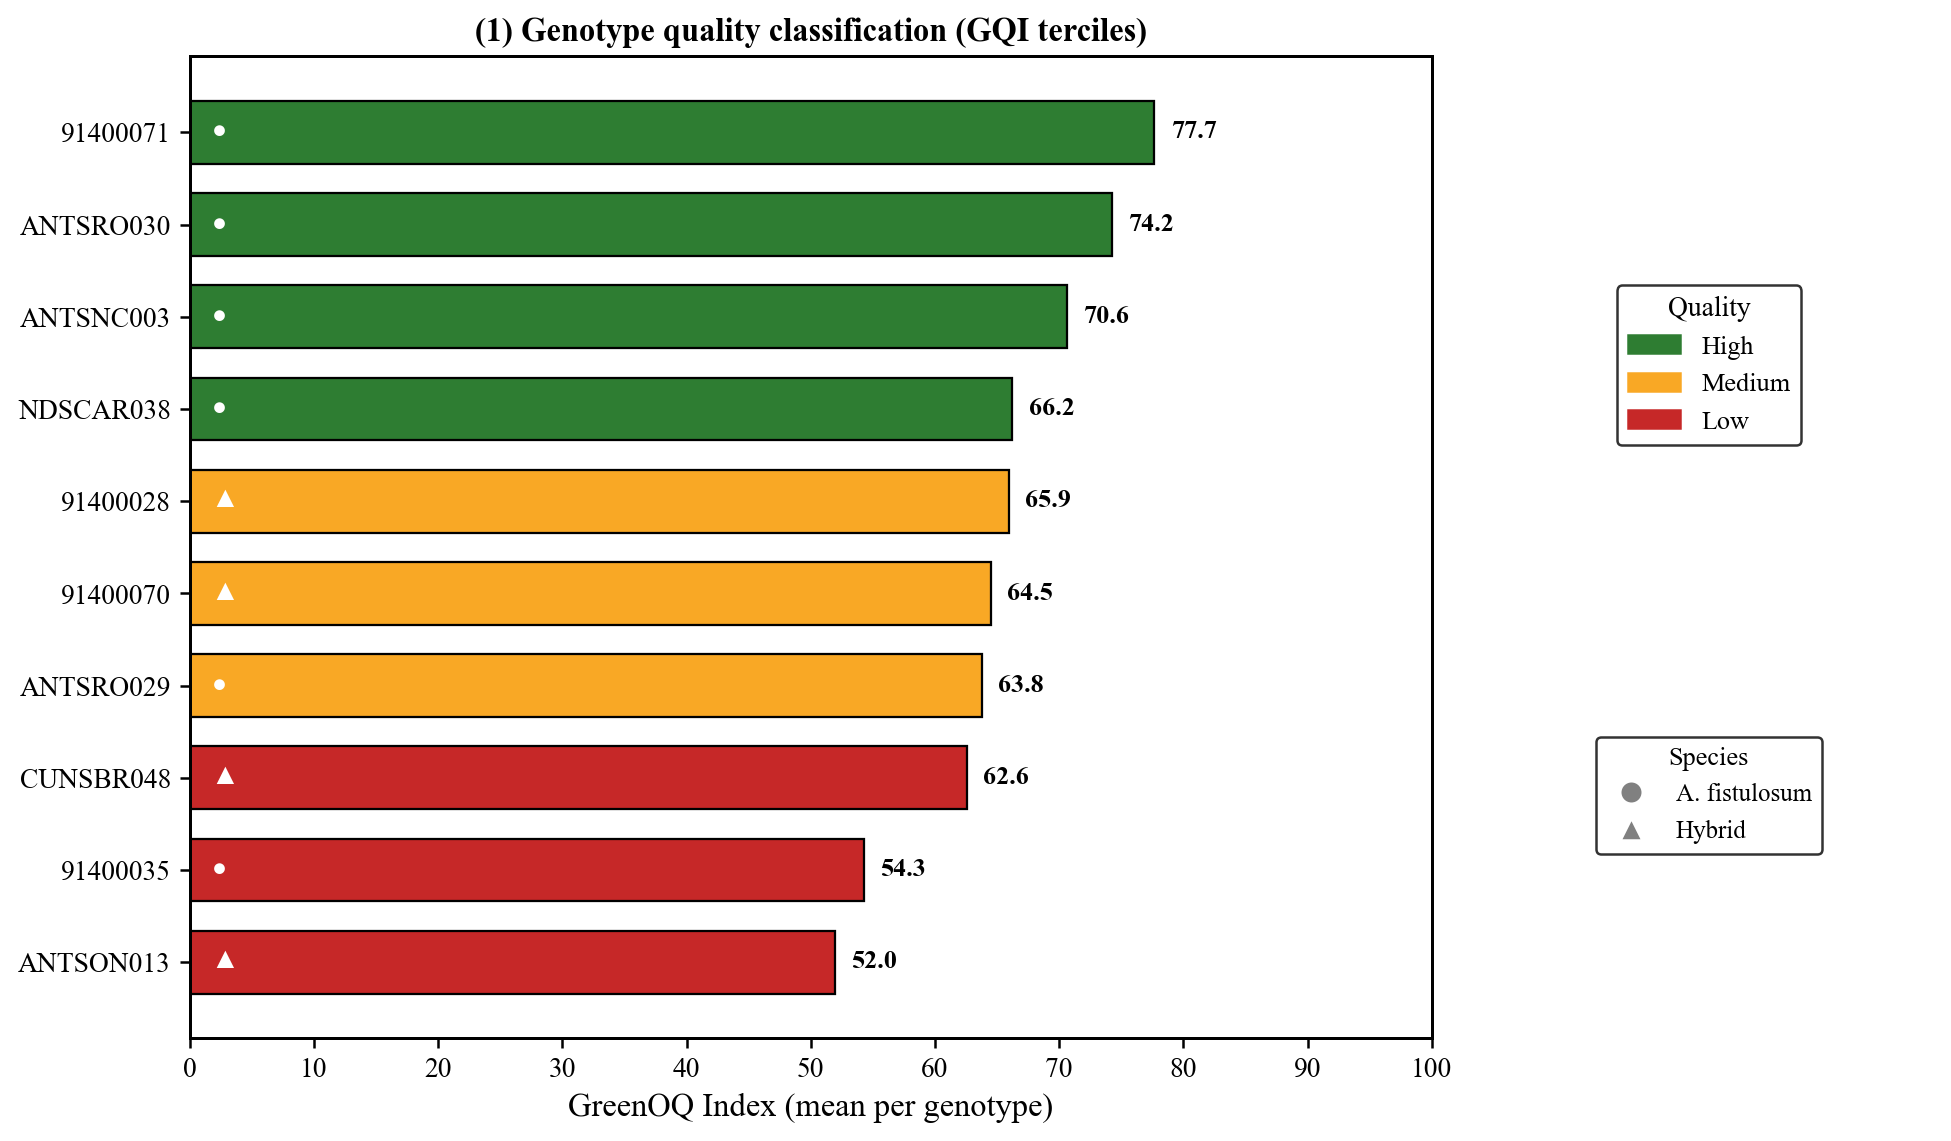

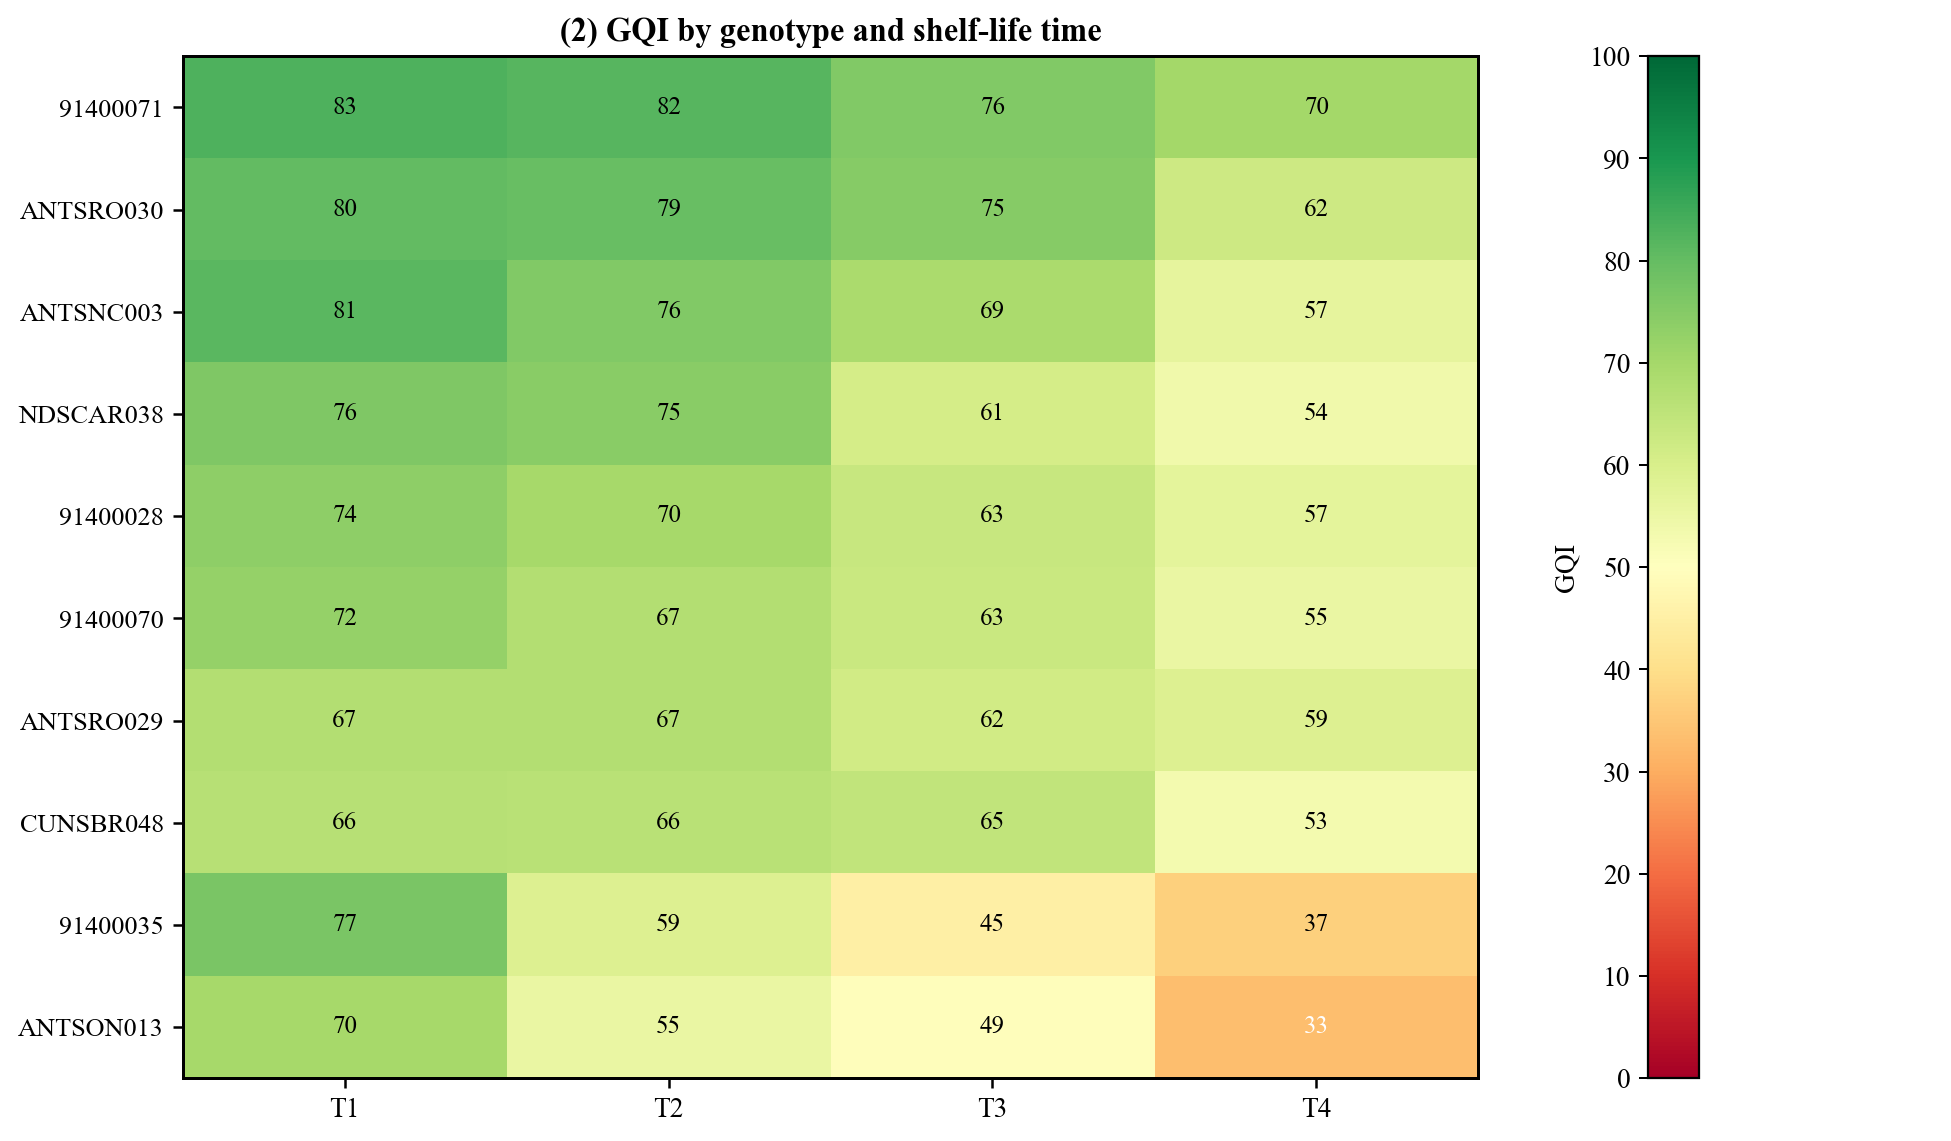

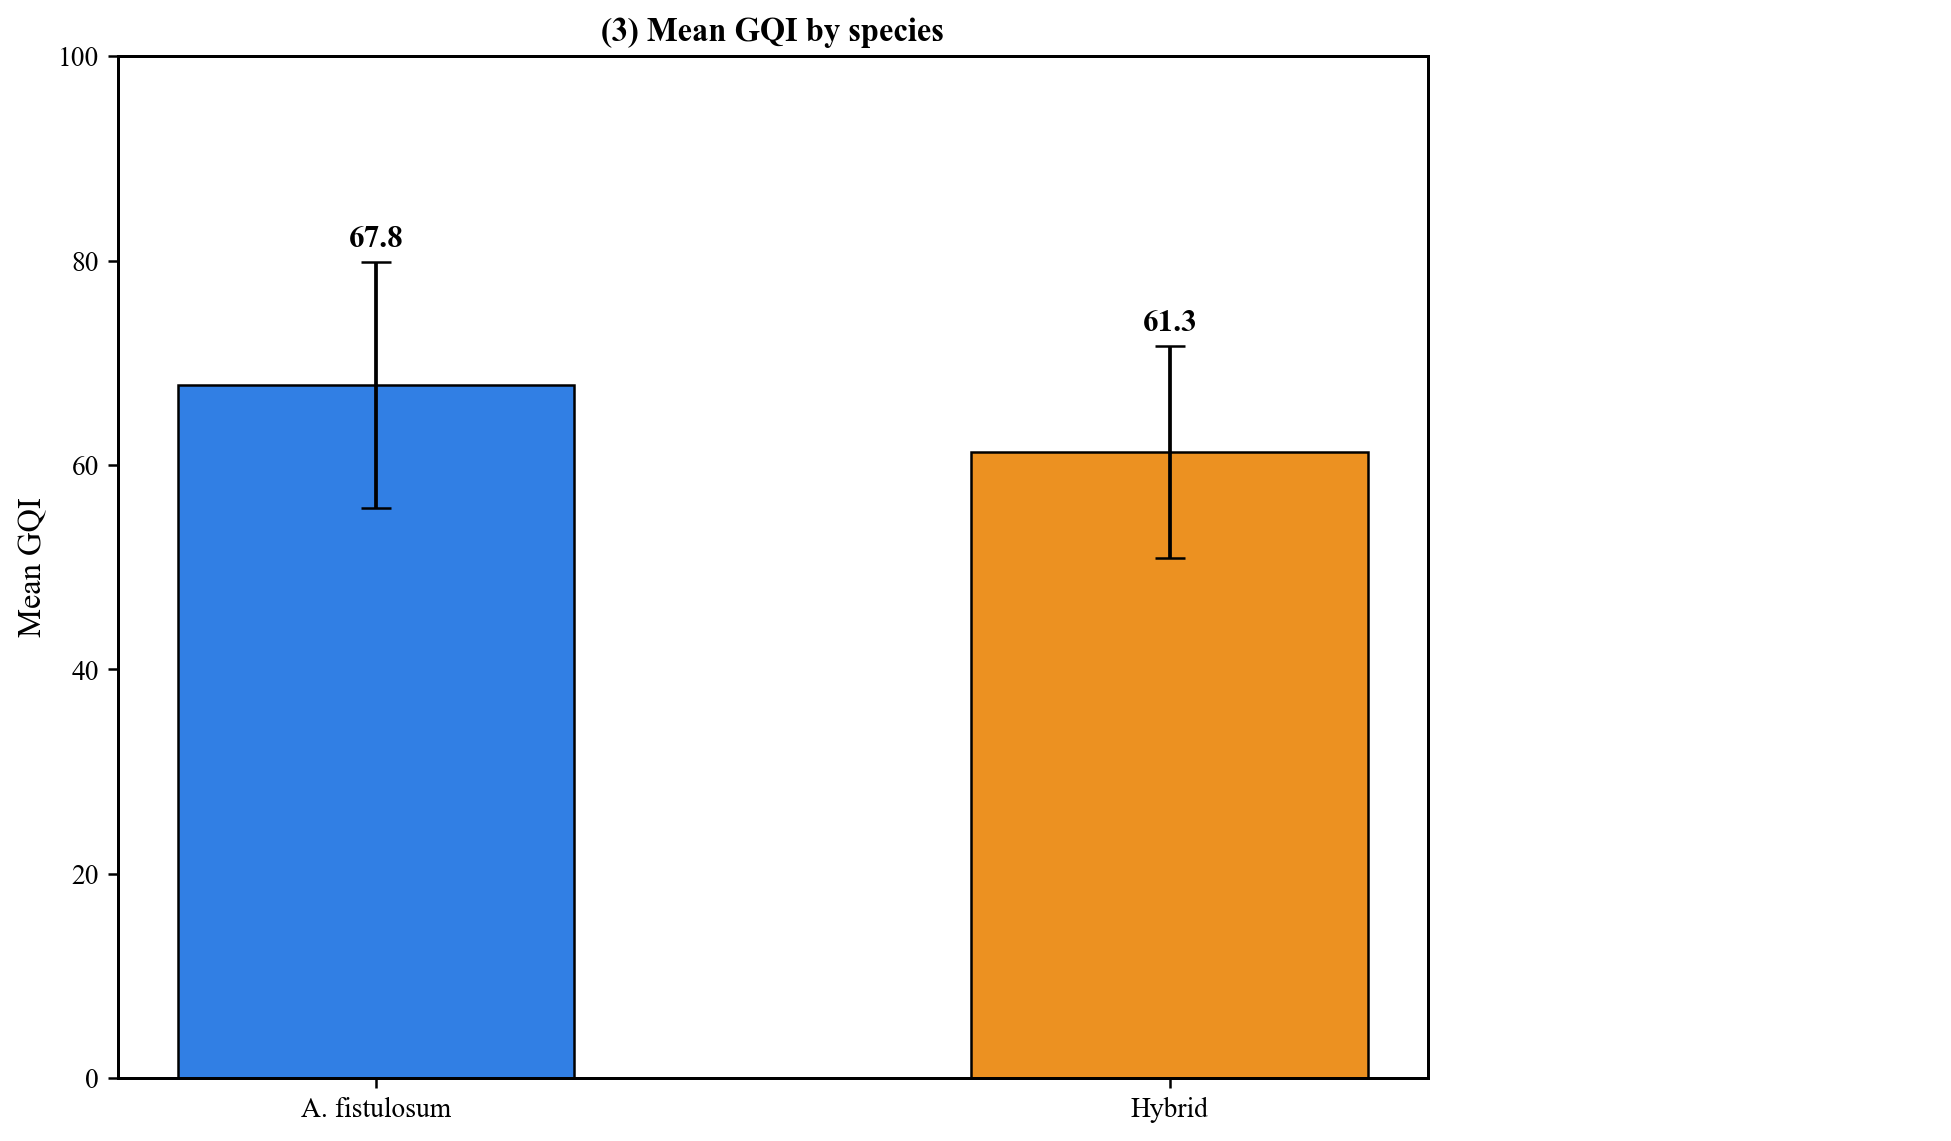

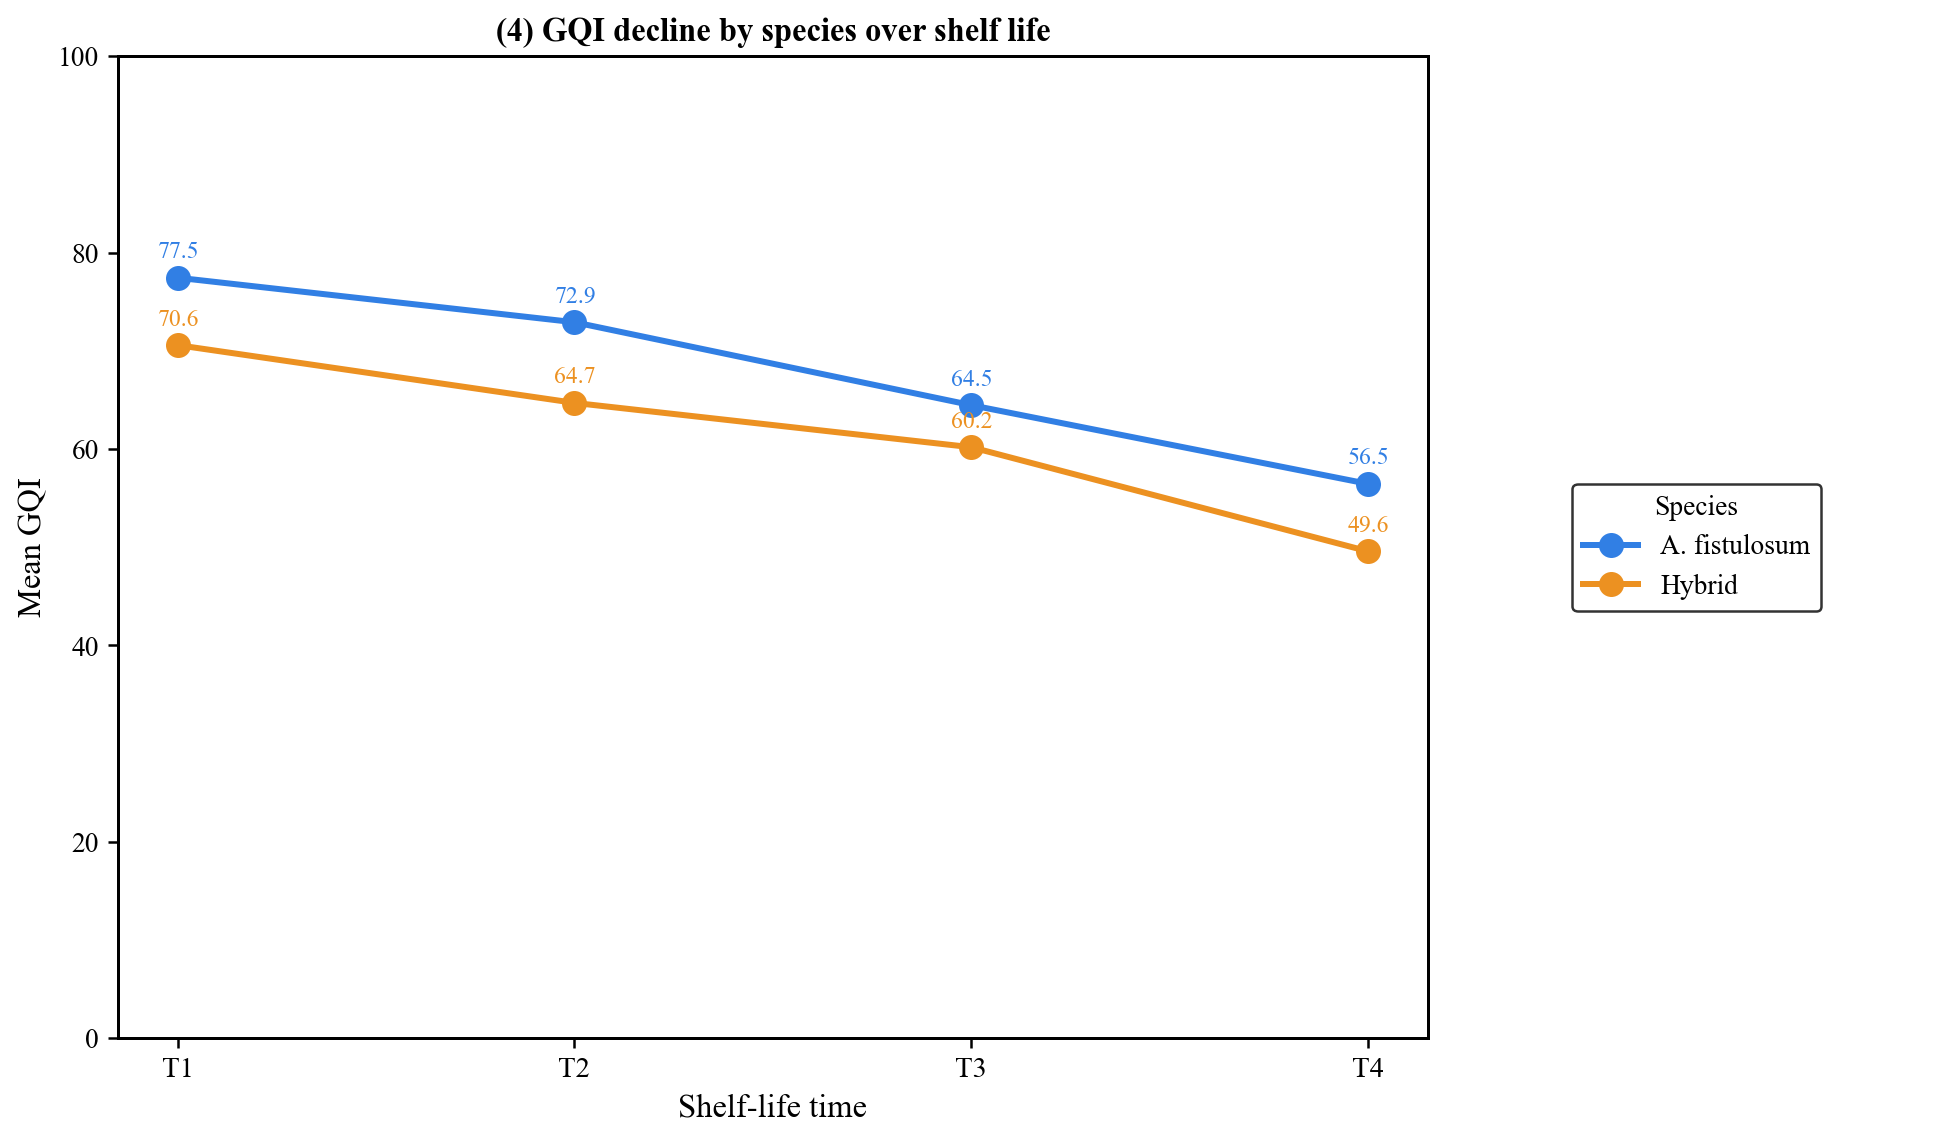

In [10]:
CLASS_COLOR = {"High": "#2E7D32", "Medium": "#F9A825", "Low": "#C62828"}
SPECIES_COLORS = ["#317FE4", "#EC9121"]

# ============================================================
# FIGURE 1 (genotype) — Classification, horizontal bars
# ============================================================
fig, (ax, axl) = plt.subplots(1, 2, figsize=FIGSIZE_QUALITY, dpi=DPI, gridspec_kw={"width_ratios": [3.6, 1.3]})
genotypes = summary.index.tolist()
values = summary["GQI"].values
y = np.arange(len(genotypes))[::-1]
ax.barh(y, values, color=[CLASS_COLOR[c] for c in summary["Class"]], edgecolor="black", lw=0.9, height=0.68)
for yi, val, sp in zip(y, values, summary["Species"].values):
    ax.text(val + 1.3, yi, f"{val:.1f}", va="center", fontsize=10.5, weight="bold")
    marker = "●" if sp == "A fistulosum" else "▲"
    ax.text(1.8, yi, marker, va="center", ha="left", fontsize=10, color="white")
ax.set_yticks(y); ax.set_yticklabels(genotypes, fontsize=11)
ax.set_xlabel("GreenOQ Index (mean per genotype)", fontsize=13)
ax.set_title("(1) Genotype quality classification (GQI terciles)", fontsize=13, weight="bold")
ax.set_xlim(0, 100); ax.set_xticks(range(0, 101, 10)); close_axes(ax)
axl.axis("off")
class_handles = [mpatches.Patch(color=CLASS_COLOR[c], label=c) for c in ["High", "Medium", "Low"]]
species_handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", label="A. fistulosum", markersize=9),
                   plt.Line2D([0], [0], marker="^", color="w", markerfacecolor="gray", label="Hybrid", markersize=9)]
class_legend = axl.legend(handles=class_handles, title="Quality", loc="upper center", fontsize=10.5, title_fontsize=11,
                          frameon=True, edgecolor="black", bbox_to_anchor=(0.5, 0.78))
axl.add_artist(class_legend)
axl.legend(handles=species_handles, title="Species", loc="upper center", fontsize=10, title_fontsize=10.5,
           frameon=True, edgecolor="black", bbox_to_anchor=(0.5, 0.32))
plt.tight_layout(); plt.show()

# ============================================================
# FIGURE 2 (genotype) — Genotype x time heatmap
# ============================================================
pivot = gqi.pivot(index="Genotype", columns="Time", values="GQI").loc[summary.index]
fig, (ax, axl) = plt.subplots(1, 2, figsize=FIGSIZE_QUALITY, dpi=DPI, gridspec_kw={"width_ratios": [3.6, 1.3]})
im = ax.imshow(pivot.values, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=10,
                color="white" if val < 35 or val > 85 else "black")
ax.set_xticks(range(pivot.shape[1])); ax.set_xticklabels([f"T{t}" for t in pivot.columns], fontsize=11)
ax.set_yticks(range(pivot.shape[0])); ax.set_yticklabels(pivot.index, fontsize=10.5)
ax.set_title("(2) GQI by genotype and shelf-life time", fontsize=13, weight="bold")
close_axes(ax)
axl.axis("off")
cbar = plt.colorbar(im, ax=axl, fraction=0.5, pad=0.0, ticks=range(0, 101, 10), location="left")
cbar.set_label("GQI", fontsize=11)
plt.tight_layout(); plt.show()

# ============================================================
# FIGURE 3 (species) — Mean GQI by species, bars
# ============================================================
species_means = gqi_species.groupby("Species")["GQI"].mean()
species_sd = gqi_species.groupby("Species")["GQI"].std()
fig, (ax, axl) = plt.subplots(1, 2, figsize=FIGSIZE_QUALITY, dpi=DPI, gridspec_kw={"width_ratios": [3.6, 1.3]})
ax.bar([SPECIES_LABEL.get(s, s) for s in species_means.index], species_means.values, yerr=species_sd.values,
       capsize=6, color=SPECIES_COLORS, edgecolor="black", lw=1.0, width=0.5)
for i, v in enumerate(species_means.values):
    ax.text(i, v + species_sd.values[i] + 1.5, f"{v:.1f}", ha="center", fontsize=12.5, weight="bold")
ax.set_ylabel("Mean GQI", fontsize=13); ax.set_ylim(0, 100)
ax.set_title("(3) Mean GQI by species", fontsize=13, weight="bold")
close_axes(ax)
axl.axis("off")
plt.tight_layout(); plt.show()

# ============================================================
# FIGURE 4 (species) — GQI over time by species, lines
# ============================================================
species_time = gqi_species.groupby(["Species", "Time"])["GQI"].mean().reset_index()
fig, (ax, axl) = plt.subplots(1, 2, figsize=FIGSIZE_QUALITY, dpi=DPI, gridspec_kw={"width_ratios": [3.6, 1.3]})
for sp, color in zip(["A fistulosum", "Hibrid"], SPECIES_COLORS):
    sub = species_time[species_time["Species"] == sp]
    ax.plot(sub["Time"], sub["GQI"], "o-", color=color, lw=2.4, ms=9, label=SPECIES_LABEL[sp])
    for t, v in zip(sub["Time"], sub["GQI"]):
        ax.text(t, v + 2, f"{v:.1f}", ha="center", fontsize=9.5, color=color)
ax.set_xticks([1, 2, 3, 4]); ax.set_xticklabels(["T1", "T2", "T3", "T4"], fontsize=11.5)
ax.set_xlabel("Shelf-life time", fontsize=13); ax.set_ylabel("Mean GQI", fontsize=13); ax.set_ylim(0, 100)
ax.set_title("(4) GQI decline by species over shelf life", fontsize=13, weight="bold")
close_axes(ax)
axl.axis("off")
axl.legend(handles=[plt.Line2D([0], [0], marker="o", color=SPECIES_COLORS[0], lw=2.4, ms=9, label="A. fistulosum"),
                    plt.Line2D([0], [0], marker="o", color=SPECIES_COLORS[1], lw=2.4, ms=9, label="Hybrid")],
           loc="center", fontsize=11, frameon=True, edgecolor="black", title="Species", title_fontsize=11)
plt.tight_layout(); plt.show()